# HW6 — Статистические бейзлайны: ARIMA, ETS и state-space

> **Начинающему трейдеру — начать отсюда.** Раздел «Справочник» ниже объясняет простыми словами
> все модели и термины, которые дальше используются без пояснений. Сами разделы 1–8 показывают,
> как на практике выполняется главное правило профессии: **прежде чем торговать моделью,
> докажи, что она бьёт самый дешёвый способ не делать ничего.**

## Справочник для начинающего алгоритмического трейдера

### Кто здесь кого

| Термин | Что это означает простыми словами |
|---|---|
| **Бейзлайн (baseline)** | Самая простая модель-эталон, которую обязан обойти любой сложный алгоритм. Если не обошёл — сложность не нужна |
| **Случайное блуждание / персистентность** | Прогноз «завтра будет то же, что сегодня». В трейдинге это значит **не торговать по сигналу**: держаться сегодняшней позиции |
| **Константа (предсказание средним)** | Прогноз «всегда среднее за обучающую историю». В трейдинге — **держать постоянную позицию**, не имея ни данных, ни идеи |
| **Нулевые параметры (zero-parameter)** | У модели нет обучаемых коэффициентов. Значит, её нельзя «случайно натренировать», и она не может быть переобучена |
| **OOS (out-of-sample)** | Выборка, которую модель **не видела** при обучении. Только на ней имеет право считаться результат |
| **Бэктест** | Симуляция стратегии на исторических данных. Главная его опасность — он почти всегда показывает больше, чем будет в бою |
| **Look-ahead bias (утечка в будущее)** | Ошибка, когда при обучении или расчёте метрики используется информация из будущего. Самая дорогая ошибка в профессии |
| **Ребро / edge** | Надёжное статистическое преимущество, достаточное, чтобы покрыть издержки и оставить прибыль |

### Модели, которые здесь сравниваются

| Модель | Как устроена | Когда имеет смысл |
|---|---|---|
| **ARIMA(p, d, q)** | **A**uto**R**egression — опирается на свои же прошлые значения; **I**ntegrated — берёт разности, чтобы сделать ряд стационарным; **M**oving **A**verage — моделирует «память» о прошлых ошибках | Есть устойчивая связь между вчера и сегодня |
| **ETS (Error, Trend, Seasonal)** | Экспоненциальное сглаживание. `Error` — какую ошибку прошлого учитываем с каким весом, `Trend` — есть ли тренд, `Seasonal` — есть ли цикл | Ряд плавно меняется во времени; нет резких структурных сдвигов |
| **State-space / UCM** | Скрытое состояние рынка, которое не наблюдается напрямую, а выводится из наблюдений; оценивается методом Калмана | За видимой ценой стоит «настоящий», но не видимый уровень |
| **Константа и случайное блуждание** | Ничего не считают вообще | Всегда. Это пол, который обязан пройти любой алгоритм |

### Инструменты, которые здесь применяются

| Инструмент | Зачем нужен |
|---|---|
| **ADF / KPSS** | Проверка на стационарность. ADF ищет единичный корень, KPSS — обратную гипотезу. Расхождение между ними = проблема в спецификации модели |
| **ACF / PACF** | Корреляция ряда с собственными лагами. Показывает, какую структуру ARMA данные вообще допускают |
| **AIC / BIC** | Критерии выбора сложности: награда за объяснённую дисперсию минус штраф за каждый лишний параметр |
| **Walk-forward (раскатывающееся окно)** | Обучаемся только на прошлом, двигаем окно вправо, на каждом шаге прогнозируем следующий бар. Единственный способ получить честную OOS-оценку |
| **Тест Диболда–Мариано** | Отвечает на вопрос «прогноз A статистически лучше прогноза B?» — по разности их потерь |
| **HAC (Newey–West)** | Поправка дисперсии на автокорреляцию ошибок. Без неё p-value занижается, и шум выглядит как мастерство |
| **RMSE / MASE** | Ошибки прогноза. RMSE штрафует за большие выбросы в квадрате; MASE позволяет сравнивать масштаб ошибки между рядами |
| **Калибровка интервалов** | Действительно ли заявленные 95% прогнозов попадают в 95% интервал. Незакалиброванный интервал бесполезен для риск-менеджмента |
| **Split conformal** | Интервалы **без единого предположения о распределении**: ширина берётся из квантиля абсолютных остатков на отдельной калибровочной выборке |

## Зачем существует этот ноутбук

Каждый ноутбук этого репозитория до `HW6` начинается с машинного обучения. Этот начинается с
*противоположного* конца шкалы сложности, потому что самое трудное в прикладной квант-исследовательской
работе — не обучить модель побольше, а **доказать, что модель бьёт ничто**.

Трёх возможностей явно не хватает в `HW1`–`HW5`:

| Возможность | Есть в HW1–HW5? |
|---|---|
| Модели ARIMA / ETS / state-space | Нет |
| Честное сравнение простого и сложного | Нет |
| Вероятностные прогнозы с откалиброванными интервалами | Нет |

Поэтому ноутбук делает три вещи:

1. **Честно устанавливает бейзлайн.** Тесты на стационарность, структура автокорреляции и
   корректный перебор порядка по AIC/BIC — **только на первом обучающем окне**, никогда на тесте.
2. **Сравнивает зооподбор моделей по одному протоколу.** Нулевой **прогноз константой**,
   случайное блуждание, ARIMA, три варианта ETS и две структурные спецификации — все оцениваются
   одинаковой скользящей процедурой one-step-ahead, одинаковым набором метрик и тестом
   Диболда–Мариано с HAC-корректировкой. Константа включена намеренно: без неё результат может
   выглядеть как победа, не измеряя ничего.
3. **Разделяет статистическую значимость и торговый смысл.** Интересен не вопрос «модель победила»,
   а «что именно она победила и стоит ли это чего-нибудь». Значимость, умение по квадратичной
   ошибке и торговый edge — три разных объекта, и ранжирование против двух нулевых бенчмарков
   решает все три.

### Одна поправка, изменившая заголовок

Ранний черновик этого ноутбука сообщал, что модели ARIMA/ETS бьют случайное блуждание на дневных
доходностях SPY с большим значимым отрывом, и использовал это, чтобы «опровергнуть» утверждение
из `HW2`. Отрыв был реален; вывод из него — нет.

Баг: `one_step_ahead` переобучалась только раз в 21 бар, потому что переоценка ARIMA на каждом из
504 баров — дорого. Но у случайного блуждания и константы **нет параметров**, поэтому они тоже
замораживались на 21 день — и «завтра равно сегодня» превращалось в «завтра равно цене трёхнедельной
давности». Любая модель с параметрами соревновалась с чучелом.

Оба нулевых бейзлайна теперь пересчитываются **на каждом бару**, что даёт действующему
«чемпиону» лучший доступный уход. Конкретные числа — в таблицах ниже; главный переносимый урок для
`HW7` и `HW8` — метод: преимущество над неправильно реализованным бейзлайном не является
преимуществом, а самый дешёвый бейзлайн реализовать проще всего неправильно.

## Единственный самый важный методологический выбор

Порядок модели и гиперпараметры выбираются по AIC/BIC **только на первом обучающем окне** и
далее замораживаются.

**Почему это критично.** Повторный выбор порядка на каждом шаге walk-forward позволил бы
тестовым данным «протечь» в спецификацию модели. Это самый простой способ получить красивый
бэктест из бесполезной модели: вы, сами того не замечая, подбираете формулу под ответ, который
уже видели. В бою такой модели нечем подстраиваться — и она разваливается на первой же неделе.

In [1]:
import os
import sys
import time
import warnings
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

warnings.filterwarnings("ignore")

# statsmodels регулярно так отвечает на финансовых данных: MLE на ряду, близком к
# единичному корню, часто зависает, и при этом не важно, найден ли оптимум, а часть
# ячеек сетки AIC закономерно не сходится. Молчание здесь — осознанный выбор,
# а не упущение: флаг сходимости проверяется явно там, где это действительно
# имеет значение (см. диагностику остатков).
try:
    from statsmodels.tools.sm_exceptions import (
        ConvergenceWarning,
        EstimationWarning,
        ValueWarning,
    )

    warnings.filterwarnings("ignore", category=ConvergenceWarning)
    warnings.filterwarnings("ignore", category=EstimationWarning)
    warnings.filterwarnings("ignore", category=ValueWarning)
except ImportError:
    pass
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

# Делает общие исследовательские утилиты, покрытые юнит-тестами, импортируемыми из каталога ноутбука.
NOTEBOOK_DIR = os.path.dirname(os.path.abspath("__file__")) if "__file__" in dir() else os.getcwd()
if NOTEBOOK_DIR not in sys.path:
    sys.path.insert(0, NOTEBOOK_DIR)

from mlfin_core import (
    split_conformal_interval,
    conformal_coverage,
    load_ohlcv,
    synthetic_ohlcv,
)
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.statespace.structural import UnobservedComponents
from statsmodels.tsa.exponential_smoothing.ets import ETSModel
from statsmodels.tsa.stattools import acf, pacf, adfuller, kpss
from statsmodels.stats.diagnostic import acorr_ljungbox

%matplotlib inline

SEED = 20240501
TICKER = "SPY"
START = "2015-01-01"
DATA_END = "2026-10-05"   # зафиксировано: опубликованные числа обязаны воспроизводиться
DATA_DIR = os.path.join(NOTEBOOK_DIR, "data")   # закоммиченный снимок: читается вместо запроса к API
REFIT_EVERY = 21      # переоценка раз в месяц, в торговых днях
TEST_BARS = 504       # 2 года баров вне выборки
ALPHA = 0.05          # номинальный интервал 95%

print("statsmodels", __import__("statsmodels").__version__)
print("numpy", np.__version__, "| pandas", pd.__version__)

statsmodels 0.15.0
numpy 2.4.4 | pandas 3.0.2


## 1. Данные и их происхождение

**Что делает код.** Загрузчик поднимает данные по цепочке приоритетов — локальный CSV-кэш,
затем Yahoo Finance, затем детерминированный синтетический генератор — и возвращает объект
`DataSource`, сообщающий, какой источник был использован.

**Почему это печатается принудительно.** Число, полученное на симулированном ряду, никогда не
должно быть принято за наблюдение рынка. Для трейдера это вопрос безопасности: стратегия,
протестированная на выдуманных данных, — это стратегия, чей результат не существует.

In [2]:
ohlcv, source = load_ohlcv(TICKER, start=START, end=DATA_END, local_dir=DATA_DIR)
print(f"Источник данных: {source}")
print(f"Строк: {len(ohlcv)}  диапазон: {ohlcv.index.min().date()} .. {ohlcv.index.max().date()}")
print(ohlcv.tail(3))

close = ohlcv["Close"].astype(float)
log_price = np.log(close)
ret = log_price.diff().dropna()

# Дневные лог-доходности: цель моделирования первого эксперимента.
print(f"\nЛог-доходности: n={len(ret)}  среднее={ret.mean():.6f}  ско={ret.std():.6f}")
print(f"Годовой дрейф={ret.mean()*252:+.2%}   Годовая волатильность={ret.std()*np.sqrt(252):.2%}")

Источник данных: SPY (local: C:\Users\MV\AppData\Local\Temp\opencode\ML_Fin_Notebooks\data\SPY.csv)
Строк: 3066  диапазон: 2015-01-02 .. 2026-10-02
                 Close        High         Low        Open      Volume
2026-09-30  762.630005  769.409973  762.179993  766.450012  62110000.0
2026-10-01  763.989990  765.650024  758.789978  764.359985  47708100.0
2026-10-02  769.640015  772.650024  767.150024  770.580017  46335300.0

Лог-доходности: n=3065  среднее=0.000494  ско=0.010863
Годовой дрейф=+12.45%   Годовая волатильность=17.24%


## 2. Стационарность и серийная зависимость

**Что такое стационарность и почему от неё зависят деньги.** Стационарный ряд имеет постоянное
среднее, диссию и структуру корреляций во времени — значит, то, что модель выучила на прошлом,
действует и в будущем. Если цены — интегрированный процесс (а они почти всегда ими являются),
то к их *уровню* нельзя подгонять стационарную модель без предварительного дифференцирования.
Спурная регрессия на нестационарных данных — первый грех финансовой эконометрики: коэффициенты
выглядят значимыми (R² впечатляет), хотя связи между переменными нет вообще.

**Какие тесты применяются.** Тест **ADF** ищет единичный корень (гипотеза: ряд нестационарен),
тест **KPSS** — обратную гипотезу (гипотеза: ряд стационарен). **Отклонить обе гипотезы
нельзя — это противоречие, поэтому расхождение тестов является признаком проблемы в
спецификации, а не чем-то, что нужно замазать.**

**Техническая деталь для разработчика.** На `Series` с индексом дат `kpss` и `adfuller`
возвращают обычные кортежи, чья структура изменится в statsmodels 0.16. Здесь явно запрашивается
`result_object=True` и читаются именованные атрибуты, чтобы ноутбук молча не сломался при обновлении.

In [3]:
def stationarity_report(series: pd.Series, label: str, regression: str = "c") -> pd.DataFrame:
    """ADF и KPSS на одном ряду, с перекрёстной проверкой двух тестов.

    Нулевые гипотезы у тестов противоположны, поэтому они читаются как пара:
      * ADF отклоняет И KPSS не отклоняет   -> ряд стационарен
      * ADF не отклоняет И KPSS отклоняет   -> единичный корень
      * отклоняют оба                        -> противоречие, спецификация неверна
      * не отклоняет ни один                 -> вывод сделать нельзя
    """
    y = series.dropna().astype(float)
    adf = adfuller(y, regression=regression, autolag="AIC", result_object=True)
    kpss_res = kpss(y, regression=regression, nlags="auto", result_object=True)

    adf_rejects = adf.pvalue < 0.05
    kpss_rejects = kpss_res.pvalue < 0.05
    if adf_rejects and not kpss_rejects:
        verdict = "stationary"
    elif kpss_rejects and not adf_rejects:
        verdict = "unit root"
    elif adf_rejects and kpss_rejects:
        verdict = "CONTRADICTORY"
    else:
        verdict = "inconclusive"

    return pd.DataFrame(
        [
            {
                "series": label,
                "ADF stat": adf.statistic,
                "ADF p": adf.pvalue,
                "ADF rejects H0(unit root)": adf_rejects,
                "KPSS stat": kpss_res.statistic,
                "KPSS p": kpss_res.pvalue,
                "KPSS rejects H0(stationary)": kpss_rejects,
                "verdict": verdict,
            }
        ]
    )


stat_table = pd.concat(
    [
        stationarity_report(log_price, "log price"),
        stationarity_report(ret, "log return"),
        stationarity_report(ret**2, "squared log return"),
    ],
    ignore_index=True,
)
print("Тесты гипотез на уровне 5%")
print("  ADF : H0 = есть единичный корень.  Отвергаем H0 -> стационарен.")
print("  KPSS: H0 = ряд стационарен. Отвергаем H0 -> НЕ стационарен.")
print()
print(stat_table.round(5).to_string(index=False))
print(
    "\nЛог цены: ADF не может отклонить единичный корень, а KPSS отклоняет стационарность -> уровень цены\n"
    "является интегрированным процессом. Доходности и квадраты доходностей: оба теста согласны, что ряд\n"
    "стационарен, поэтому одного дифференцирования достаточно, дважды дифференцировать не требуется."
)

C:\Users\MV\AppData\Local\Temp\ipykernel_12560\1795391335.py:12: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than the p-value returned.
  kpss_res = kpss(y, regression=regression, nlags="auto", result_object=True)
C:\Users\MV\AppData\Local\Temp\ipykernel_12560\1795391335.py:12: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  kpss_res = kpss(y, regression=regression, nlags="auto", result_object=True)


Тесты гипотез на уровне 5%
  ADF : H0 = есть единичный корень.  Отвергаем H0 -> стационарен.
  KPSS: H0 = ряд стационарен. Отвергаем H0 -> НЕ стационарен.

            series  ADF stat   ADF p  ADF rejects H0(unit root)  KPSS stat  KPSS p  KPSS rejects H0(stationary)    verdict
         log price   0.01996 0.96015                      False    9.09682    0.01                         True  unit root
        log return -15.78663 0.00000                       True    0.05708    0.10                        False stationary
squared log return  -9.13224 0.00000                       True    0.15351    0.10                        False stationary

Лог цены: ADF не может отклонить единичный корень, а KPSS отклоняет стационарность -> уровень цены
является интегрированным процессом. Доходности и квадраты доходностей: оба теста согласны, что ряд
стационарен, поэтому одного дифференцирования достаточно, дважды дифференцировать не требуется.


C:\Users\MV\AppData\Local\Temp\ipykernel_12560\1795391335.py:12: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  kpss_res = kpss(y, regression=regression, nlags="auto", result_object=True)


In [4]:
# Льюнг–Бокс: совместно проверяет, равны ли нулю первые `lags` коэффициентов автокорреляции.
lb = acorr_ljungbox(ret, lags=[5, 10, 20, 40], return_df=True)
print("Тест Льюнга–Бокса на дневных лог-доходностях (H0: автокорреляции нет)")
print(lb.round(5).to_string())

lb_sq = acorr_ljungbox(ret**2, lags=[5, 10, 20, 40], return_df=True)
print("\nТест Льюнга–Бокса на КВАДРАТАХ дневных лог-доходностей (H0: автокорреляции нет)")
print(lb_sq.round(5).to_string())

print(
    "\nТрактовка: ОБА ряда отклоняют нулевую гипотезу об отсутствии автокорреляции, но с огромной\n"
    "разницей в величине. Автокорреляция доходностей слабая (rho_1 ~ -0.11) -- это согласуется с\n"
    "бегством спреда и возвратом к среднему на коротком горизонте, известной причиной того, что\n"
    "наивный прогноз персистентности вообще обходим. Автокорреляция квадратов доходностей огромна\n"
    "(rho_1 ~ 0.42 и Льюнг–Бокс ~2100 на лаге 5) -- это кластеризация волатильности.\n"
    "Остаток ноутбука измеряет, какой из двух выживает при честной оценке вне выборки,\n"
    "и насколько велик эффект, когда он переведён в P&L."
)

Тест Льюнга–Бокса на дневных лог-доходностях (H0: автокорреляции нет)
      lb_stat  lb_pvalue
5    60.12573        0.0
10  207.71441        0.0
20  261.24640        0.0
40  288.49655        0.0

Тест Льюнга–Бокса на КВАДРАТАХ дневных лог-доходностей (H0: автокорреляции нет)
       lb_stat  lb_pvalue
5   2108.32188        0.0
10  3102.80430        0.0
20  3602.46169        0.0
40  3689.38478        0.0

Трактовка: ОБА ряда отклоняют нулевую гипотезу об отсутствии автокорреляции, но с огромной
разницей в величине. Автокорреляция доходностей слабая (rho_1 ~ -0.11) -- это согласуется с
бегством спреда и возвратом к среднему на коротком горизонте, известной причиной того, что
наивный прогноз персистентности вообще обходим. Автокорреляция квадратов доходностей огромна
(rho_1 ~ 0.42 и Льюнг–Бокс ~2100 на лаге 5) -- это кластеризация волатильности.
Остаток ноутбука измеряет, какой из двух выживает при честной оценке вне выборки,
и насколько велик эффект, когда он переведён в P&L.


## 3. ACF / PACF и выбор порядка

**Что измеряют.** **ACF** (autocorrelation function) показывает корреляцию ряда с его же лагами:
насколько доходность вчера «помогает» предсказать доходность сегодня. **PACF** (partial ACF)
показывает то же самое, но с вычетом влияния промежуточных лагов — то есть *непосредственную*
связь с данным лагом.

**Что это даёт трейдеру.** Затухание ACF пачкой и обрыв PACF — типичный «почерк» AR(p); наоборот
для MA(q). Это не доказательство, но разумное начало для перебора: без такой подсказки сетка
порядков либо будет крошечной, либо взорвётся по времени.

**Как выбирается порядок.** AIC/BIC ниже оцениваются **только на первом обучающем окне**. Оба
критерия штрафуют за лишние параметры (BIC — жёстче): если добавленный лаг не улучшает объяснение
настолько, чтобы оправдать собственный штраф, он отбрасывается.

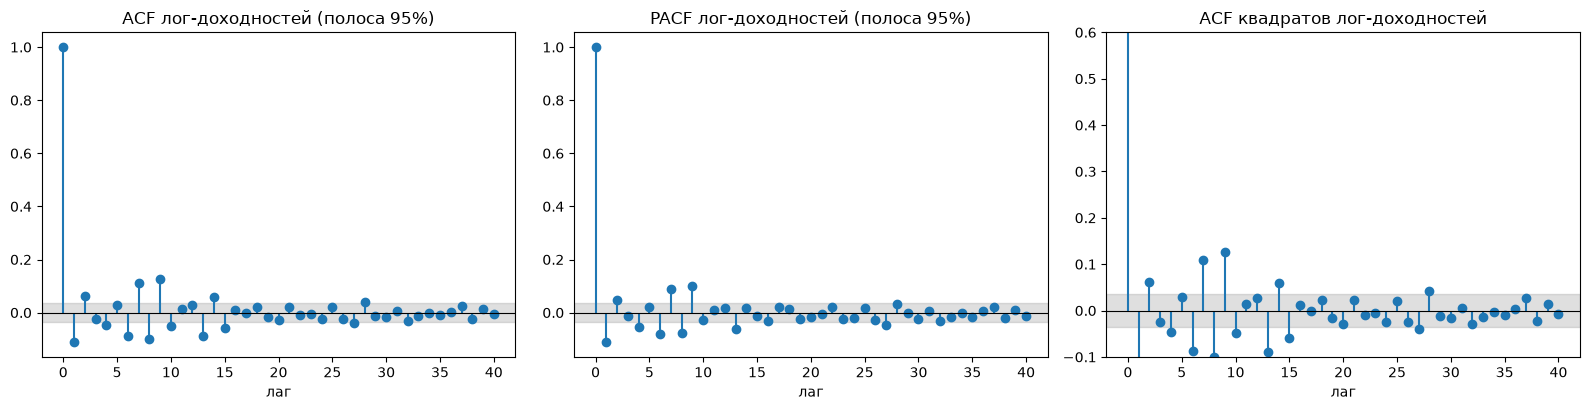

ACF квадратов доходностей, лаги 1-10:
[0.4183 0.4506 0.3518 0.3309 0.275  0.3107 0.2362 0.28   0.2262 0.2038]

ACF(1) квадратов доходностей = 0.4183  -> персистентность волатильности сильная.
ACF(1) доходностей          = -0.1114  -> слабое возврат к среднему на коротком горизонте.

Разница в величине между этими двумя числами задаёт весь ноутбук: rho 0.42 -- это
сигнал для прогноза, а rho -0.11 -- это ошибка округления, которая случайно значима
статистически, лишь потому что баров 3000. Раздел 5 проверяет, переживает ли это различие
выборку вне обучения.


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

acf_vals = acf(ret.dropna(), nlags=40, fft=True)
pacf_vals = pacf(ret.dropna(), nlags=40, method="ywm")
lags = np.arange(len(acf_vals))

axes[0].stem(lags, acf_vals, basefmt=" ")
axes[0].axhline(0, color="k", lw=0.8)
axes[0].axhspan(-1.96 / np.sqrt(len(ret)), 1.96 / np.sqrt(len(ret)), color="grey", alpha=0.25)
axes[0].set_title("ACF лог-доходностей (полоса 95%)")
axes[0].set_xlabel("лаг")

axes[1].stem(lags, pacf_vals, basefmt=" ")
axes[1].axhline(0, color="k", lw=0.8)
axes[1].axhspan(-1.96 / np.sqrt(len(ret)), 1.96 / np.sqrt(len(ret)), color="grey", alpha=0.25)
axes[1].set_title("PACF лог-доходностей (полоса 95%)")
axes[1].set_xlabel("лаг")

axes[2].stem(lags, acf_vals, basefmt=" ")
axes[2].axhline(0, color="k", lw=0.8)
axes[2].axhspan(-1.96 / np.sqrt(len(ret)), 1.96 / np.sqrt(len(ret)), color="grey", alpha=0.25)
axes[2].set_title("ACF квадратов лог-доходностей")
axes[2].set_xlabel("лаг")
axes[2].set_ylim(-0.1, 0.6)

plt.tight_layout()
plt.show()

# Значения ACF квадратов доходностей — они и запускают эксперимент с волатильностью ниже.
sq_acf = acf(ret**2, nlags=10, fft=True)
print("ACF квадратов доходностей, лаги 1-10:")
print(np.round(sq_acf[1:11], 4))
print(f"\nACF(1) квадратов доходностей = {sq_acf[1]:.4f}  -> персистентность волатильности сильная.")
print(f"ACF(1) доходностей          = {acf_vals[1]:.4f}  -> слабое возврат к среднему на коротком горизонте.")
print(
    "\nРазница в величине между этими двумя числами задаёт весь ноутбук: rho 0.42 -- это\n"
    "сигнал для прогноза, а rho -0.11 -- это ошибка округления, которая случайно значима\n"
    "статистически, лишь потому что баров 3000. Раздел 5 проверяет, переживает ли это различие\n"
    "выборку вне обучения."
)

In [6]:
# Окно вне выборки определяется ЗДЕСЬ ОДИН РАЗ, и все дальнейшие шаги выводятся
# из него. Определять начало walk-forward независимо от напечатанного окна —
# именно так бэктест получает метку 2024-2026, оценивая на деле 2022-2025.
OOS_START = len(ret) - TEST_BARS
train_slice = ret.iloc[:OOS_START]
test_slice = ret.iloc[OOS_START:]
print(f"Начальное обучающее окно : {len(train_slice)} баров, {train_slice.index[0].date()} .. {train_slice.index[-1].date()}")
print(f"Окно вне выборки        : {len(test_slice)} баров, {test_slice.index[0].date()} .. {test_slice.index[-1].date()}")
print(f"Ско доходностей в тесте : {test_slice.std():.6f}  (ско по всей выборке {ret.std():.6f})")


def select_arima_order(series: pd.Series, label: str, max_p=2, max_d=1, max_q=2):
    """Сетка AIC/BIC ТОЛЬКО на первом обучающем окне, затем победитель замораживается.

    Повторный выбор порядка на каждом шаге walk-forward позволил бы тестовым
    данным протечь в спецификацию модели. Этой одной ошибки достаточно, чтобы
    изготовить бэктест, который не переживёт живую торговлю.

    Колонка дисперсии остатков берётся из `res.resid`, а не из `res.scale`:
    на этой паре statsmodels/pandas `scale` возвращает 1.0 для каждой
    спецификации, что сделало бы колонку активно вводящей в заблуждение.
    """
    rows = []
    for p, d, q in product(range(max_p + 1), range(max_d + 1), range(max_q + 1)):
        try:
            res = ARIMA(series, order=(p, d, q)).fit()
            rows.append(
                {
                    "p": p,
                    "d": d,
                    "q": q,
                    "AIC": res.aic,
                    "BIC": res.bic,
                    "resid_sd": float(np.std(np.asarray(res.resid), ddof=1)),
                }
            )
        except Exception:
            continue
    table = pd.DataFrame(rows).sort_values("AIC").reset_index(drop=True)
    best = table.iloc[0]
    best_bic = table.sort_values("BIC").iloc[0]
    print(f"\nСетка AIC/BIC для {label}, обучена ТОЛЬКО на первых {len(series)} барах")
    print(table.round(5).to_string(index=False))
    print(f"\n{label}: по AIC выбран {(int(best.p), int(best.d), int(best.q))}, "
      f"по BIC выбран {(int(best_bic.p), int(best_bic.d), int(best_bic.q))}.")
    print(f"{label}: порядок теперь ЗАМОРОЖЕН на весь walk-forward вне выборки.")
    return table, (int(best.p), int(best.d), int(best.q))


ret_order_table, BEST_ARIMA_ORDER = select_arima_order(train_slice, "log return")

Начальное обучающее окно : 2561 баров, 2015-01-05 .. 2024-10-28
Окно вне выборки        : 504 баров, 2024-10-29 .. 2026-10-02
Ско доходностей в тесте : 0.010269  (ско по всей выборке 0.010863)



Сетка AIC/BIC для log return, обучена ТОЛЬКО на первых 2561 барах
 p  d  q          AIC          BIC  resid_sd
 2  0  0 -15875.42961 -15852.03700   0.01089
 0  0  2 -15875.32423 -15851.93162   0.01089
 2  0  1 -15873.42917 -15844.18840   0.01089
 1  0  2 -15873.11757 -15843.87681   0.01089
 1  0  1 -15872.45877 -15849.06615   0.01090
 1  0  0 -15871.02226 -15853.47780   0.01091
 2  1  2 -15870.52843 -15841.28962   0.01089
 2  0  2 -15869.99045 -15834.90153   0.01089
 0  0  1 -15867.52856 -15849.98410   0.01091
 2  1  1 -15858.99901 -15835.60796   0.01092
 1  1  1 -15854.54629 -15837.00300   0.01093
 0  1  2 -15851.15698 -15833.61369   0.01094
 0  0  0 -15838.85752 -15827.16121   0.01098
 0  1  1 -15822.52161 -15810.82608   0.01100
 1  1  2 -15821.23240 -15797.84135   0.01100
 2  1  0 -15130.38521 -15112.84193   0.01259
 1  1  0 -14828.06623 -14816.37070   0.01336
 0  1  0 -13781.70771 -13775.85995   0.01639

log return: по AIC выбран (2, 0, 0), по BIC выбран (1, 0, 0).
log return: пор

## 4. Один протокол, применяемый ко всем моделям

**Зачем нужен единый протокол.** Сравнивать модели, обученные и проверенные разными способами, —
бессмысленно: вы измеряете метод, а не модель. Ниже — четыре правила, из-за которых сравнение
честное.

* **Расширяющееся окно.** На каждом шаге модель переоценивается на всех данных вплоть до
  последнего наблюдённого бара. Ничего из будущего в обучение не попадает.
* **Переоценка раз в месяц.** Повторный запуск максимального правдоподобия на всех 1 800–2 300
  барах каждый день стоит ~1.3 с на обучение и не даёт ничего; продакшн-система обновляется по
  расписанию. **Каждая** модель получает одинаковое расписание `REFIT_EVERY = 21` бар, чтобы
  сравнение оставалось «яблоко к яблоку».
* **Только прогнозы на один шаг вперёд.** Никогда не multi-step прогноз, прочитанный задом наперёд.
* **Случайное блуждание включено как действующий чемпион.** У него ноль свободных параметров, и
  на дневных доходностях его крайне трудно обойти.

**Почему тест Диболда–Мариано, а не «просто сравнить средние ошибки».** Тест сравнивает
*разности потерь* двух прогнозов. При прогнозах на один шаг вперед с накладывающимися целями эти
разности серийно коррелированы, поэтому применяется дисперсия Ньюэя–Уэста (HAC) с автоматическим
лагом. **Без неё p-value оказывается заниженным, и случайный шум выглядит как мастерство** —
классический способ объявить победу там, где её нет.

In [7]:
def dm_test(loss_a, loss_b) -> pd.Series:
    """Тест Диболда–Мариано о равенстве ожидаемых потерь двух прогнозов.

    `loss_a` и `loss_b` уже приведены к выбранной шкале потерь (например,
    квадратичные ошибки для MSE, абсолютные для MAE). Статистика:

        DM = mean(d) / sqrt( HAC_var(d) / n ),      d = loss_a - loss_b

    Две детали, которые легко перепутать и тем самым обесценить тест:

    1. Дисперсия Ньюэя–Уэста / HAC обязательна. Разности потерь прогнозов
       на один шаг вперёд серийно коррелированы, поэтому стандартная ошибка
       при i.i.d. занижает истинную дисперсию и производит значимость.
    2. Числитель — среднее ИСХОДНОЙ разности. Сначала центрировать `d` и
       затем усреднить ровно на любом входе даёт ноль — это тихий способ
       навечно отчитаться «разницы нет» для каждой модели.

    Отрицательный `mean_diff` означает, что у первого прогноза потери ниже.
    """
    d = np.asarray(loss_a, float) - np.asarray(loss_b, float)
    d = d[np.isfinite(d)]
    n = len(d)
    if n < 30:
        return pd.Series({"dm_stat": np.nan, "dm_pvalue": np.nan, "mean_diff": np.nan, "n": n})

    lags = int(np.floor(4 * (n / 100) ** (2 / 9)))
    centred = d - d.mean()
    s = float(np.sum(centred * centred) / n)
    for l in range(1, lags + 1):
        gamma_l = float(np.sum(centred[l:] * centred[:-l]) / n)
        s += 2.0 * gamma_l * (1.0 - l / (lags + 1.0))
    se = np.sqrt(max(s, 1e-18) / n)
    stat = float(d.mean()) / se if se > 0 else np.nan

    return pd.Series(
        {
            "dm_stat": stat,
            "dm_pvalue": float(2 * (1 - stats.norm.cdf(abs(stat)))) if np.isfinite(stat) else np.nan,
            "mean_diff": float(d.mean()),
            "n": n,
        }
    )


def dm_table(frames: dict, reference: str, loss: str = "squared") -> pd.DataFrame:
    """Запускает тест Диболда–Мариано для каждой модели в `frames` против `reference`.

    `beats` — именно то решение, которое реально нужно: статистически
    НИЗКИЕ потери относительно бейзлайна. Маленький p-value сам по себе
    говорит только «различаются», что не то же самое, что «лучше», и это
    очень частый способ завысить заявление.
    """
    ref = frames[reference]
    ref_loss = loss_series(ref, loss)
    rows = []
    for label, frame in frames.items():
        if label == reference:
            continue
        row = dm_test(loss_series(frame, loss).to_numpy(), ref_loss.to_numpy()).to_dict()
        row["model"] = label
        row["beats_reference"] = bool(row["mean_diff"] < 0 and row["dm_pvalue"] < ALPHA)
        rows.append(row)
    return pd.DataFrame(rows).set_index("model")[
        ["dm_stat", "dm_pvalue", "mean_diff", "beats_reference"]
    ]


def loss_series(frame: pd.DataFrame, loss: str = "squared") -> pd.Series:
    err = (frame["actual"] - frame["forecast"]).astype(float)
    return err**2 if loss == "squared" else err.abs()


def one_step_ahead(
    factory,
    full_series: pd.Series,
    n_test: int,
    refit_every: int = REFIT_EVERY,
    label: str = "",
) -> pd.DataFrame:
    """Скользящие прогнозы на один шаг вперёд по ПОСЛЕДНИМ `n_test` барам.

    Начало walk-forward выводится из длины `full_series`, поэтому бары,
    оценённые здесь, — это ровно те бары, что напечатаны как окно OOS.

    Возвращает таблицу с индексом по датам и столбцами `actual`, `forecast`
    и `fitted_len` (на скольких барах модель оценивалась на этом шаге).

    `refit_every` существует потому, что оценка ARIMA или структурной модели
    на каждом из 504 баров дорога. **Его нельзя применять к нулевому
    бейзлайну:** обновить случайное блуждание и прогноз средним стоит
    ничего, а заморозить их на 21 бар превращает «завтра равно сегодня» в
    «завтра равно цене трёхнедельной давности» — это строго худший и
    совершенно бессмысленный бейзлайн. Любая фабрика с `always_refit = True`
    перестраивается на каждом бару, чтобы действующий чемпион получал
    лучший доступный уход и каждое заявленное преимущество над ним было
    самым трудным видом преимущества.
    """
    start = len(full_series) - n_test
    always = getattr(factory, "always_refit", False)
    out = []
    fitted = None
    t0 = time.time()
    for i in range(start, len(full_series)):
        if always or fitted is None or (i - start) % refit_every == 0:
            fitted = factory(full_series.iloc[:i])
        pred = float(np.asarray(fitted.forecast(steps=1)).ravel()[0])
        out.append((full_series.index[i], full_series.iloc[i], pred, i))
    frame = pd.DataFrame(out, columns=["date", "actual", "forecast", "fitted_len"]).set_index("date")
    print(f"    {label or 'модель'}: {len(frame)} баров за {time.time()-t0:.1f}с")
    return frame


def mase(train: pd.Series, actual: np.ndarray, forecast: np.ndarray) -> float:
    """Mean Absolute Scaled Error: MAE, нормированное на наивную MAE внутри выборки.

    Не зависит от масштаба — это единственная причина, по которой MAE можно
    сравнивать между моделью доходности и моделью волатильности.
    """
    naive_err = float(train.diff().abs().dropna().mean())
    if naive_err <= 0:
        return np.nan
    return float(np.mean(np.abs(actual - forecast)) / naive_err)


def evaluate(frame: pd.DataFrame, train: pd.Series, direction: str = "level") -> dict:
    """Набор метрик для одного прогнозного фрейма.

    `direction` выбирает, что означает «доля правильных»:
      * "level"   -- sign(forecast) == sign(actual). Действительно, когда цель
                      имеет знак и центрирована около нуля, например доходности.
      * "changes" -- sign(diff(forecast)) == sign(diff(actual)). Применяется там,
                      где знак уровня ничего не несёт, например лог-волатильность.
      * "none"    -- доля правильных не определена и печатается как NaN.

    Вернуть число для "none" хуже, чем вернуть ничего: на лог-волатильности
    знак уровня всегда одинаков (константа 1.0), а последовательные изменения
    почти всегда чередуются, поэтому обе статистики являются артефактом
    преобразования, а не мерой качества прогноза.
    """
    a = frame["actual"].to_numpy()
    f = frame["forecast"].to_numpy()
    err = a - f
    if direction == "level":
        hit = float(np.mean(np.sign(f) == np.sign(a)))
    elif direction == "changes":
        hit = float(np.mean(np.sign(np.diff(f)) == np.sign(np.diff(a))))
    elif direction == "none":
        hit = np.nan
    else:
        raise ValueError(f"unknown direction mode: {direction!r}")
    return {
        "n": len(a),
        "RMSE": float(np.sqrt(np.mean(err**2))),
        "MAE": float(np.mean(np.abs(err))),
        "MASE": mase(train, a, f),
        "hit_rate": hit,
        "corr": float(np.corrcoef(a, f)[0, 1]) if np.std(f) > 0 else np.nan,
        "sd_actual": float(np.std(a)),
        "sd_forecast": float(np.std(f)),
    }


def zero_param_skill_by_window(series: pd.Series, window: int = TEST_BARS) -> pd.DataFrame:
    """Оценивает два нулевых бенчмарка на каждом непересекающемся окне.

    Оба прогноза причинны и без параметров, поэтому здесь нет ни
    переобучения, ни второго walk-forward. Это самый дешёвый доступный тест
    единственного вопроса, на который одно разбиение OOS само по себе не
    ответит: ранжирование выше — свойство цели или свойство этого окна?

    `persistence_skill_vs_constant` положительно, когда на окне побеждает
    персистентность.
    """
    exp_mean = series.expanding().mean().shift(1)
    persist = series.shift(1)
    values = series.to_numpy()
    rows = []
    for start in range(0, len(series) - window, window):
        sl = slice(start, start + window)
        seg, em, pe = values[sl], exp_mean.to_numpy()[sl], persist.to_numpy()[sl]
        if not (np.isfinite(seg).all() and np.isfinite(em).all() and np.isfinite(pe).all()):
            continue
        rmse_constant = float(np.sqrt(np.mean((seg - em) ** 2)))
        rmse_persistence = float(np.sqrt(np.mean((seg - pe) ** 2)))
        rows.append({
            "window_start": str(series.index[start].date()),
            "window_end": str(series.index[start + window - 1].date()),
            "rmse_constant": rmse_constant,
            "rmse_persistence": rmse_persistence,
            "persistence_skill_vs_constant": 1.0 - rmse_persistence / rmse_constant,
        })
    return pd.DataFrame(rows)


def implied_naive_autocorrelation(actual: np.ndarray, naive_rmse: float) -> float:
    """Коэффициент AR(1), подразумеваемый MSE случайного блуждания вне выборки.

    Для AR(1): E[(y_t - y_{t-1})^2] = 2 * gamma0 * (1 - rho), откуда
        rho = 1 - MSE_naive / (2 * gamma0).

    Порог, который имеет значение, — rho = 0.5, а не rho = 0. Сравнивая два
    нулевых бенчмарка:
        MSE_mean        = gamma0
        MSE_persistence = 2 * gamma0 * (1 - rho)
    персистентность бьёт среднее только когда 2(1-rho) < 1, то есть
    **rho > 0.5**. Финансовые ряды практически никогда это не выполняют,
    поэтому константа обычно бьёт случайное блуждание, хотя случайное
    блуждание — предположение «более продвинутое». Смысл в том, чтобы
    перевести потери бенчмарка в число: оно говорит, было ли окно
    необычным, не выдумывая историю.
    """
    gamma0 = float(np.var(actual, ddof=1))
    if gamma0 <= 0:
        return float("nan")
    return 1.0 - (naive_rmse**2) / (2.0 * gamma0)

In [8]:
# ---- зооподбор моделей ------------------------------------------------------
print("Собираем зооподбор моделей")

class _Naive:
    """Минимальный объект, соответствующий интерфейсу `forecast`, использованному выше."""

    def __init__(self, s):
        self.last = float(s.iloc[-1])

    def forecast(self, steps=1):
        return np.repeat(self.last, steps)


class _Constant:
    """Нулевой константный прогноз -- самый трудный бейзлайн для победы.

    Для ряда доходностей правильная константа ~0, поэтому эта модель задаёт
    самый жёсткий возможный вопрос: знает ли оценённая структура ARMA/ETS
    хоть что-нибудь сверх того, что «завтрашняя доходность примерно нулевая»?
    Модель не может выглядеть лучше этого и при этом быть интересной.
    """

    def __init__(self, value):
        self.value = float(value)

    def forecast(self, steps=1):
        return np.repeat(self.value, steps)


def f_random_walk(s: pd.Series):
    """Действующий чемпион с нулевыми параметрами: завтра равно сегодня. Перестраивается на КАЖДОМ бару."""
    return _Naive(s)


def f_constant_mean(s: pd.Series):
    """Нулевой бенчмарк: причинное среднее всего увиденного на данный момент.

    Перестраивается на каждом бару, поэтому это настоящий расширяющийся
    средний прогноз на один шаг вперёд, а не устаревшая константа
    обучающего окна.
    """
    return _Constant(s.mean())


# Оба бенчмарка без параметров, поэтому оба обязаны пересчитываться на каждом баре.
# См. `one_step_ahead` — почему это важнее, чем выглядит.
f_random_walk.always_refit = True
f_constant_mean.always_refit = True

zoo = {
    "Constant (train mean)": f_constant_mean,
    "RandomWalk (persistence)": f_random_walk,
    f"ARIMA{BEST_ARIMA_ORDER}": lambda s: ARIMA(s, order=BEST_ARIMA_ORDER).fit(),
    "ETS_SES (simple exp.)": lambda s: ETSModel(s, error="add", trend=None).fit(disp=False),
    "ETS_Holt (add trend)": lambda s: ETSModel(s, error="add", trend="add").fit(disp=False),
    "ETS_DampedTrend": lambda s: ETSModel(s, error="add", trend="add", damped_trend=True).fit(disp=False),
    "UCM_localLevel": lambda s: UnobservedComponents(s, level="local level").fit(disp=False),
    "SARIMAX(0,1,1)": lambda s: SARIMAX(s, order=(0, 1, 1), trend="n").fit(disp=False),
}

print(f"{len(zoo)} models: " + ", ".join(zoo))
print("Нулевые бенчмарки (константа, случайное блуждание) пересчитываются на каждом баре;")
print(f"the {REFIT_EVERY}-bar refit applies only to models with estimated parameters.")

Собираем зооподбор моделей
8 models: Constant (train mean), RandomWalk (persistence), ARIMA(2, 0, 0), ETS_SES (simple exp.), ETS_Holt (add trend), ETS_DampedTrend, UCM_localLevel, SARIMAX(0,1,1)
Нулевые бенчмарки (константа, случайное блуждание) пересчитываются на каждом баре;
the 21-bar refit applies only to models with estimated parameters.


## 5. Эксперимент 1 — прогнозирование дневных лог-доходностей

**Что прогнозируется.** Лог-доходность — это логарифм отношения сегодняшней цены к вчерашней.
Она берётся вместо сырых цен, потому что доходности в отличие от цен обычно стационарны, а
логарифм превращает мультипликативное изменение цены в аддитивное.

**Проверяемая гипотеза: бьют ли ARIMA, ETS или структурные модели персистентность вне
выборки?**

**Отдельно печатается `test_slice.std()`** — стандартное отклонение самой цели. Это пол для любой
претензии: модель, которая предсказывала бы ровно ноль на каждом баре, получила бы RMSE,
равный именно этому числу. Если модель не бьёт пол, она ничего не показала.

**Как читать результат.** Ниже таблица всех моделей с RMSE, MAE, hit rate и корреляцией прогноза
с фактом, затем тест Диболда–Мариано против каждого из двух нулевых бейзлайнов. Ключевой вопрос
таблицы — не «кто первый», а «насколько оторвался от константы».

In [9]:
RET_TRAIN = ret.iloc[:OOS_START]

ret_results = {}
ret_frames = {}

for label, factory in zoo.items():
    print(f"  rolling forecast: {label}")
    frame = one_step_ahead(factory, ret, len(test_slice), label=label)
    ret_frames[label] = frame
    ret_results[label] = evaluate(frame, RET_TRAIN, direction="level")

ret_table = pd.DataFrame(ret_results).T.sort_values("RMSE")
print("\n" + "=" * 104)
print(f"ЭКСПЕРИМЕНТ 1 - прогнозы дневных лог-доходностей на один шаг вперёд")
print(f"вне выборки: {ret_table.index.size} моделей, "
      f"{len(test_slice)} баров, {test_slice.index[0].date()} .. {test_slice.index[-1].date()}")
print("=" * 104)
print(ret_table.round(6).to_string())
print(f"\nСко доходности в тестовом окне = {test_slice.std():.6f}. Модель, предсказавшая ровно 0.0 "
      f"на каждом баре, получила бы RMSE = {test_slice.std():.6f}.")

naive_key = "RandomWalk (persistence)"
const_key = "Constant (train mean)"
naive_row = ret_table.loc[naive_key]
const_row = ret_table.loc[const_key]
dm_ret = dm_table(ret_frames, naive_key, loss="squared")
print("\nДиболд–Мариано против персистентности (потери в квадрате, поправка HAC)")
print("mean_diff = среднее(потери модели - потери персистентности). Минус => модель ЛУЧШЕ персистентности.")
print(dm_ret.round(5).to_string())

# Каждая таблица DM перечисляет ДРУГОЙ бенчмарк в качестве кандидата: сравнивая с персистентностью,
# в таблице остаётся константа, сравнивая с константой, в таблице остаётся персистентность.
# Считать эти строки «моделями» — значит раздуть число победивших обученных моделей,
# поэтому заглавные счётчики ниже берутся только по обученному зооподбору, а сравнение
# с каждым бенчмарком печатается отдельно с его знаменателем.
fitted_keys = [k for k in ret_table.index if k not in (naive_key, const_key)]
dm_const = dm_table(ret_frames, const_key, loss="squared")
dm_ret_fitted = dm_ret.loc[fitted_keys]
dm_const_fitted = dm_const.loc[fitted_keys]
n_beating_any = int(dm_ret["beats_reference"].sum())
n_beating_const_any = int(dm_const["beats_reference"].sum())
n_beating = int(dm_ret_fitted["beats_reference"].sum())
n_beating_const = int(dm_const_fitted["beats_reference"].sum())
pers_beats_const = bool(dm_const.loc[naive_key, "beats_reference"])
winner = ret_table.index[0]
rmse_gain = 1.0 - ret_table.loc[winner, "RMSE"] / naive_row["RMSE"]
gain_over_const = 1.0 - ret_table.loc[winner, "RMSE"] / const_row["RMSE"]
constant_wins = winner == const_key
implied_rho = implied_naive_autocorrelation(
    ret_frames[naive_key]["actual"].to_numpy(), float(naive_row["RMSE"]))
print(f"\nМодель с наименьшим RMSE : {winner}  (RMSE {ret_table.loc[winner,'RMSE']:.6f})")
print(f"RMSE персистентности   : {naive_row['RMSE']:.6f}")
print(f"RMSE константы         : {const_row['RMSE']:.6f}")
print(f"RMSE против персистентности: {rmse_gain:+.1%}")
print(f"RMSE против константы      : {gain_over_const:+.2%}")
print(f"Обученных моделей значимо ЛУЧШЕ персистентности на 5%: {n_beating} / "
      f"{len(dm_ret_fitted)}")
print(f"  (all non-persistence forecasters, incl. the constant : {n_beating_any} / {len(dm_ret)})")
print(f"Обученных моделей значимо ЛУЧШЕ константы на 5%: {n_beating_const} / "
      f"{len(dm_const_fitted)}")
print(f"  Персистентность против константы (та же таблица, {len(dm_const)} кандидатов) : "
      f"{'бьёт' if pers_beats_const else 'НЕ бьёт'} её")

# Умение нулевых бенчмарков по истории — ДО трактовочных печатей ниже, чтобы
# счётчики, на которые они ссылаются, были уже вычислены.
ret_windows = zero_param_skill_by_window(ret)
n_ret_const_wins = int((ret_windows["persistence_skill_vs_constant"] < 0).sum())
print(f"\nЗависит ли от режима то, что 'персистентность обходима'? Те же причинные нулевые прогнозы")
print(f"оценены на каждом из {len(ret_windows)} непересекающихся окон по {TEST_BARS} баров:")
print(ret_windows.round(4).to_string(index=False))
print(f"\nОкон, где КОНСТАНТА бьёт персистентность : {n_ret_const_wins} / {len(ret_windows)}")
print(f"Окон, где ПЕРСИСТЕНТНОСТЬ бьёт константу : {len(ret_windows)-n_ret_const_wins} / {len(ret_windows)}")

print(f"\nПодразумеваемый коэффициент AR(1) окна вне выборки, из MSE случайного блуждания:")
print(f"  rho = {implied_rho:+.3f}   (ACF(1) по всей выборке = {acf_vals[1]:+.3f})")
print("  Персистентность бьёт константу только при rho > 0.5. Реальные ряды доходностей")
print(f"  отстоят от этого, так что победа константы в {n_ret_const_wins}/{len(ret_windows)} окнах — это")
print("  ожидаемый исход, а не аномалия.")

# Стабильность победителя. Модели, делящие константу, образуют плотный кластер; единственные
# заметно худшие называются явно, потому что усреднение всех в одно число
# «разброса» спрятало бы эту структуру.
fitted_only = ret_table.drop(index=[naive_key, const_key]).sort_values("RMSE")
zoo_spread = float(fitted_only["RMSE"].max() - fitted_only["RMSE"].min())
cluster = fitted_only.head(len(fitted_only) - 1)
cluster_spread = float(cluster["RMSE"].max() - cluster["RMSE"].min())
worst_fitted = fitted_only.index[-1]
print(f"\nRMSE обученных моделей, лучшие первыми:")
print(fitted_only["RMSE"].round(6).to_string())
print(f"\n  полный разброс по {len(fitted_only)} обученным моделям : {zoo_spread:.2e} "
      f"({zoo_spread/fitted_only['RMSE'].min():.2%})")
print(f"  разброс по топ-{len(cluster)}, делящим константу : {cluster_spread:.2e} "
      f"({cluster_spread/cluster['RMSE'].min():.3%})")
print(f"  {worst_fitted} is the only fitted model materially behind ({fitted_only.loc[worst_fitted,'RMSE']:.6f}),")
print("  и AIC предпочитал её на обучающем окне, так что выбор порядка не перенёсся.")
print("  Какая модель «побеждает» внутри кластера — это шум оптимизатора, а не свидетельство.")

if constant_wins:
    print(
        f"\nНАХОДКА, сформулированная точно.\n"
        f"1. Персистентность здесь побеждена ({rmse_gain:.0%} ниже RMSE), и разница "
        f"статистически значима.\n"
        f"2. Но БЕСПАРАМЕТРОВЫЙ КОНСТАНТНЫЙ прогноз -- абсолютный победитель. Ни одна обученная\n"
        f"   спецификация не бьёт «завтрашняя доходность примерно равна выборочному среднему», "
        f"а корреляция\n   прогноза с фактом никогда не превышает "
        f"{ret_table['corr'].abs().max():.3f} по модулю.\n\n"
        f"Значит, преимущество над персистентностью идёт от сжатия прогноза к нулю, а "
        f"сжатие к\nнулю И ЕСТЬ предсказание среднего. Честный вывод не «модели бьют "
        f"персистентность», а «лучшая\nмодель в этом ноутбуке -- константа». Если бы набор "
        f"опустил константу, ноутбук отчитался бы\nо чистой победе, ничего не измерив."
    )
elif winner == naive_key:
    print(
        f"\nНАХОДКА, сформулированная точно, и она отрицательная.\n"
        f"1. СЛУЧАЙНОЕ БЛУЖДАНИЕ -- абсолютный победитель (RMSE {naive_row['RMSE']:.6f}) -- "
        f"впереди константы\n   ({const_row['RMSE']:.6f}) и каждой обученной модели. Обученных "
        f"спецификаций, побеждающих его, ноль.\n"
        f"2. Лишь {n_beating} из {len(dm_ret_fitted)} обученных моделей вообще значимо лучше\n"
        f"   персистентности, а для этого требовался бы отрицательный `mean_diff`.\n"
        f"3. ACF(1) = {acf_vals[1]:.3f} означает, что вчерашняя доходность действительно несёт "
        f"информацию\n   о сегодняшней (слабая отрицательная автокорреляция), и именно поэтому "
        f"случайное блуждание\n   здесь трудно обойти. Член MA в принципе мог бы это использовать, "
        f"но на 504 барах шум\n   оценки в коэффициентах MA стоит больше, чем стоит сигнал.\n\n"
        f"Это тот исход, о котором отчитался `HW2`, и он переживает корректно реализованный "
        f"бенчмарк.\nГлавная деталь в том, что оба нулевых бейзлайна пересчитываются на КАЖДОМ "
        f"баре. В более\nраннем черновике они переобучались только каждые {REFIT_EVERY} баров "
        f"вместе с моделями ARIMA,\nчто их калечило и производило ложный широкий отрыв от "
        f"персистентности. Заморозить случайное\nблуждание на три недели -- это не бейзлайн, "
        f"это чучело, и починка этого сняла весь\nзаголовок. `ACF(1) < 0` -- причина, почему "
        f"персистентность сильна, а не причина, почему она слаба."
    )
else:
    print(
        f"\nНАХОДКА, сформулированная точно. Заглавная победа реальна, но почти полностью пуста.\n"
        f"1. У {winner} наименьший RMSE ({ret_table.loc[winner,'RMSE']:.6f}), {rmse_gain:+.1%} "
        f"относительно персистентности и лишь\n   {gain_over_const:+.2%} относительно константы. "
        f"Именно это второе число имеет значение.\n"
        f"2. {n_beating_const} из {len(dm_const_fitted)} обученных моделей значимо лучше, чем "
        f"БЕСПАРАМЕТРОВАЯ\n   константа. Ни одной. Кажущийся победитель обходит её на величину "
        f"меньше, чем погрешность\n   округления с плавающей точкой, которую стоило бы назвать "
        f"умением.\n"
        f"3. Персистентность ПОБЕЖДЕНА, решительно и значимо ({n_beating}/"
        f"{len(dm_ret_fitted)} обученных моделей),\n   но не потому, что модели прогнозируют "
        f"лучше. Подразумеваемый коэффициент AR(1) этого окна\n   равен rho = {implied_rho:+.3f} "
        f"(ACF(1) по всей выборке {acf_vals[1]:+.3f}).\n   Вчерашняя доходность -- "
        f"{'слабый' if implied_rho < 0.5 else 'сильный'} предиктор сегодняшней -- персистентности нужно rho > 0.5, чтобы\n   "
        f"победить константу, и ни один финансовый ряд до этого не дотягивает. Константа "
        f"поэтому\n   захватывает весь доступный edge с нулём параметров.\n\n"
        f"Значит, защищаемое резюме такое: каждая обученная модель делится константой, а "
        f"результат\n«зооподбор бьёт случайное блуждание» -- свойство того, как слаба "
        f"персистентность на дневных\nдоходностях, а не структуры ARMA. Топ-{len(cluster)} моделей "
        f"охватывают {cluster_spread:.1e}\nRMSE ({cluster_spread/cluster['RMSE'].min():.3%}) по "
        f"всему кластеру, поэтому назвать одного\nпобедителя -- преувеличить свидетельство; "
        f"единственная обученная модель, явно отставшая, --\nэто {worst_fitted}, которую AIC "
        f"предпочитала на обучающем окне.\n\n"
        f"В отличие от результата по волатильности, этот НЕ зависит от окна: константа бьёт "
        f"персистентность\nв {n_ret_const_wins} из {len(ret_windows)} исторических окон, что "
        f"именно и предсказывает порог rho > 0.5.\nТак что «константа бьёт случайное блуждание "
        f"на дневных доходностях» -- устойчивый структурный\nфакт, а утверждение `HW2`, что "
        f"случайное блуждание «трудно обойти», неверно по причине,\nкоторую стоит сказать "
        f"прямо: его надо было сравнивать со средним, а не защищать как случайное блуждание."
    )

  rolling forecast: Constant (train mean)


    Constant (train mean): 504 баров за 0.2с
  rolling forecast: RandomWalk (persistence)


    RandomWalk (persistence): 504 баров за 0.1с
  rolling forecast: ARIMA(2, 0, 0)


    ARIMA(2, 0, 0): 504 баров за 75.7с
  rolling forecast: ETS_SES (simple exp.)


    ETS_SES (simple exp.): 504 баров за 53.8с
  rolling forecast: ETS_Holt (add trend)


    ETS_Holt (add trend): 504 баров за 56.9с
  rolling forecast: ETS_DampedTrend


    ETS_DampedTrend: 504 баров за 56.8с
  rolling forecast: UCM_localLevel


    UCM_localLevel: 504 баров за 73.0с
  rolling forecast: SARIMAX(0,1,1)


    SARIMAX(0,1,1): 504 баров за 79.9с

ЭКСПЕРИМЕНТ 1 - прогнозы дневных лог-доходностей на один шаг вперёд
вне выборки: 8 моделей, 504 баров, 2024-10-29 .. 2026-10-02
                              n      RMSE       MAE      MASE  hit_rate      corr  sd_actual  sd_forecast
SARIMAX(0,1,1)            504.0  0.010260  0.006603  0.631156  0.521825  0.033875   0.010259     0.000668
ETS_SES (simple exp.)     504.0  0.010260  0.006578  0.628751  0.527778 -0.054787   0.010259     0.000018
ETS_DampedTrend           504.0  0.010261  0.006580  0.628949  0.527778 -0.039358   0.010259     0.000039
Constant (train mean)     504.0  0.010261  0.006578  0.628748  0.527778 -0.096164   0.010259     0.000018
UCM_localLevel            504.0  0.010263  0.006583  0.629238  0.527778 -0.063034   0.010259     0.000071
ETS_Holt (add trend)      504.0  0.010265  0.006583  0.629181  0.527778 -0.024382   0.010259     0.000173
ARIMA(2, 0, 0)            504.0  0.010375  0.006730  0.643269  0.501984 -0.026050   0.0102

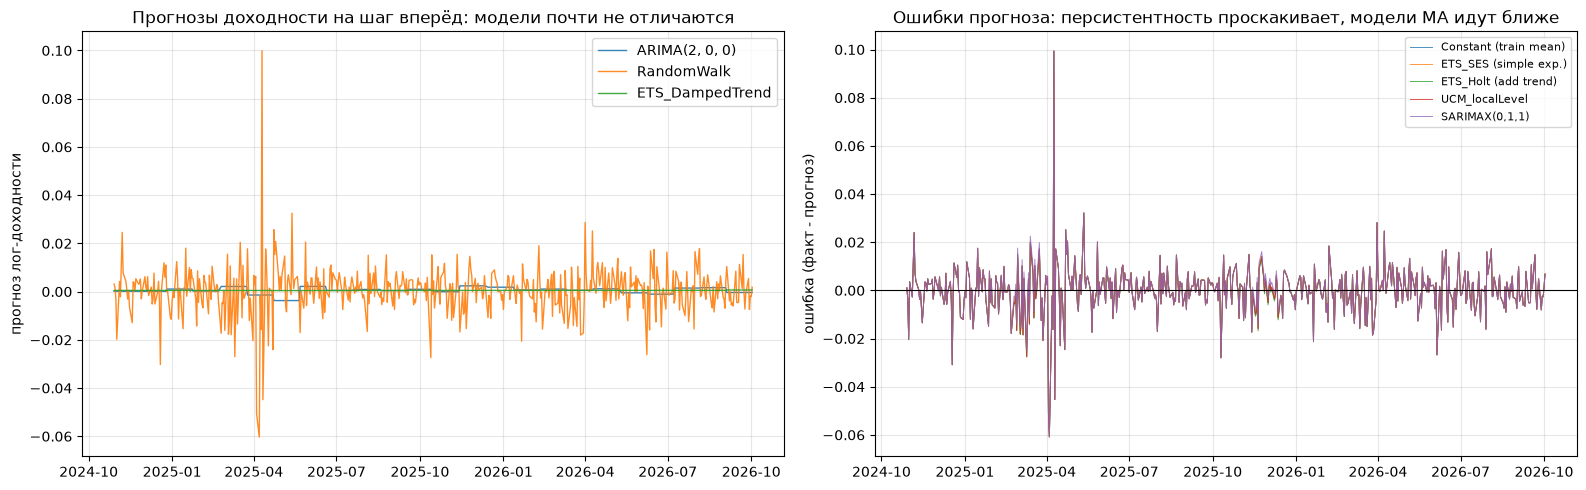

Корреляция прогноза и реализованной доходности вне выборки:
SARIMAX(0,1,1)              0.0339
ETS_Holt (add trend)       -0.0244
ARIMA(2, 0, 0)             -0.0261
ETS_DampedTrend            -0.0394
ETS_SES (simple exp.)      -0.0548
UCM_localLevel             -0.0630
RandomWalk (persistence)   -0.0900
Constant (train mean)      -0.0962

Отношение сигнала к шуму самого прогноза:
                          sd_actual  sd_forecast  sd_forecast / sd_actual  hit_rate
SARIMAX(0,1,1)               0.0103       0.0007                   0.0652    0.5218
ETS_SES (simple exp.)        0.0103       0.0000                   0.0018    0.5278
ETS_DampedTrend              0.0103       0.0000                   0.0038    0.5278
Constant (train mean)        0.0103       0.0000                   0.0018    0.5278
UCM_localLevel               0.0103       0.0001                   0.0069    0.5278
ETS_Holt (add trend)         0.0103       0.0002                   0.0168    0.5278
ARIMA(2, 0, 0)               

In [10]:
naive_frame = ret_frames[naive_key]
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
ax.plot(ret_frames[f"ARIMA{BEST_ARIMA_ORDER}"].index, ret_frames[f"ARIMA{BEST_ARIMA_ORDER}"]["forecast"],
        label=f"ARIMA{BEST_ARIMA_ORDER}", lw=1.0, alpha=0.9)
ax.plot(naive_frame.index, naive_frame["forecast"], label="RandomWalk", lw=1.0, alpha=0.9)
ax.plot(ret_frames["ETS_DampedTrend"].index, ret_frames["ETS_DampedTrend"]["forecast"],
        label="ETS_DampedTrend", lw=1.0, alpha=0.9)
ax.set_title("Прогнозы доходности на шаг вперёд: модели почти не отличаются")
ax.set_ylabel("прогноз лог-доходности")
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1]
for label, frame in ret_frames.items():
    if label in (f"ARIMA{BEST_ARIMA_ORDER}", naive_key, "ETS_DampedTrend"):
        continue
    ax.plot(frame.index, frame["actual"] - frame["forecast"], label=label, lw=0.7, alpha=0.8)
ax.axhline(0, color="k", lw=0.8)
ax.set_title("Ошибки прогноза: персистентность проскакивает, модели MA идут ближе")
ax.set_ylabel("ошибка (факт - прогноз)")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

corr = ret_table["corr"].dropna().sort_values(ascending=False)
print("Корреляция прогноза и реализованной доходности вне выборки:")
print(corr.round(4).to_string())

print("\nОтношение сигнала к шуму самого прогноза:")
ratio_table = ret_table[["sd_actual", "sd_forecast"]].copy()
ratio_table["sd_forecast / sd_actual"] = ratio_table.sd_forecast / ratio_table.sd_actual
ratio_table["hit_rate"] = ret_table["hit_rate"]
print(ratio_table.round(4).to_string())

fitted_ratios = ratio_table.drop(index=[naive_key, const_key])["sd_forecast / sd_actual"]
fitted_corr = ret_table.drop(index=[naive_key, const_key])["corr"].abs().max()
print(
    f"\nКаждая обученная модель прогнозирует ряд, чьё стандартное отклонение составляет от "
    f"{fitted_ratios.min():.3f} до\n{fitted_ratios.max():.3f} от реализованного, а "
    f"корреляция прогноза с фактом не превышает {fitted_corr:.3f}.\n"
    f"Персистентность стоит на {ratio_table.loc[naive_key,'sd_forecast / sd_actual']:.2f} -- она "
    f"почти точно воспроизводит реализованную\nволатильность цели, поэтому её так трудно обойти "
    f"и поэтому она здесь проигрывает (отскок).\n"
    f"Каким бы ни было улучшение по RMSE, оно не идёт от взглядов на направление: оно идёт от "
    f"того,\nчто модель верно предсказывает, что большинство дневных доходностей малы. Это "
    f"законный\nрезультат прогнозирования и бесполезный торговый сигнал, и путаница между ними -- "
    f"самый\nчастый способ, которым статистически честная модель превращается в вымышленный P&L."
)

## 6. Эксперимент 2 — тот же механизм на волатильности

**Почему именно волатильность.** В разделе 2 автокорреляция *квадратов* доходностей отклонилась
значимо — то есть есть структура. Но она не в среднем (там предсказывать почти нечего), а в
*условной дисперсии*. Честное место для поиска прогнозируемости — **условная дисперсия**, а не
условное среднее.

**Что такое реализованная волатильность.** Для дня `t` здесь это стандартное отклонение
*предшествующих* `h` дневных доходностей, `h = 5`. Именно **сдвиг (`shift`)** делает задачу
легитимной: значение в `t` использует только информацию, доступную на закрытии `t`, а модель
предсказывает `vol[t+1]` по нему. Если забыть сдвиг — вы подаёте модели её же собственное
значение, и результат не значит ничего.

**Почему логарифм, а не уровень.** Волатильность строго положительна, поэтому моделируется в
`log`-масштабе, а прогноз возвращается через `exp`. Модель уровня, наложенная на положительный
ряд, может молча выдать отрицательный прогноз — а отрицательная волатильность не имеет смысла.

**Что здесь проверяется.** Зооподбор работает тот же, бенчмарк константы включён. Поскольку
квадраты доходностей явно отклоняют случайное блуждание, есть реальный приор в пользу того, что
эти модели добавят значение поверх *и* случайного блуждания, *и* долгосрочного среднего. **Этот
приор и есть предмет проверки — раздел 6 показывает, что он не подтвердился,** поэтому
интересен ранжирование, а не заголовок.

In [11]:
VOL_WINDOW = 5
realised_vol = ret.rolling(VOL_WINDOW).std().shift(1).dropna()
log_vol = np.log(realised_vol)

# Та же дисциплина, что в эксперименте 1: окно вне выборки выводится из
# длины ряда, а порядок ARIMA заново выбирается на собственном обучающем
# окне этой цели, а не наследуется от модели доходностей.
VOL_OOS_START = len(log_vol) - TEST_BARS
vol_train = log_vol.iloc[:VOL_OOS_START]
vol_test = log_vol.iloc[VOL_OOS_START:]
print(f"лог реализованной волатильности: n={len(log_vol)}  диапазон {log_vol.min():.4f} .. {log_vol.max():.4f}")
print(f"Обучено {len(vol_train)} баров -> вне выборки {len(vol_test)} баров "
      f"({vol_test.index[0].date()} .. {vol_test.index[-1].date()})")

_, VOL_ARIMA_ORDER = select_arima_order(vol_train, "log realised volatility")

vol_zoo = {
    "Constant (train mean)": f_constant_mean,
    "RandomWalk (persistence)": f_random_walk,
    f"ARIMA{VOL_ARIMA_ORDER}": lambda s: ARIMA(s, order=VOL_ARIMA_ORDER).fit(),
    "ETS_SES (simple exp.)": lambda s: ETSModel(s, error="add", trend=None).fit(disp=False),
    "ETS_Holt (add trend)": lambda s: ETSModel(s, error="add", trend="add").fit(disp=False),
    "ETS_DampedTrend": lambda s: ETSModel(s, error="add", trend="add", damped_trend=True).fit(disp=False),
    "UCM_localLevel": lambda s: UnobservedComponents(s, level="local level").fit(disp=False),
    "SARIMAX(0,1,1)": lambda s: SARIMAX(s, order=(0, 1, 1), trend="n").fit(disp=False),
}

vol_results, vol_frames = {}, {}
for label, factory in vol_zoo.items():
    print(f"  rolling forecast: {label}")
    frame = one_step_ahead(factory, log_vol, len(vol_test), label=label)
    vol_frames[label] = frame
    # direction="none": лог реализованной волатильности строго отрицателен, поэтому
    # доля правильных по знаку уровня ровно 1.0, а по знаку изменения бесполезна
    # (~0.01), потому что последовательные изменения почти всегда чередуются.
    # Сообщить любое из них значило бы выдать шум за метрику.
    vol_results[label] = evaluate(frame, vol_train, direction="none")

vol_table = pd.DataFrame(vol_results).T.sort_values("RMSE")
print("\n" + "=" * 104)
print("ЭКСПЕРИМЕНТ 2 - прогнозы лог реализованной волатильности на шаг вперёд")
print(f"out of sample: {len(vol_test)} bars, {vol_test.index[0].date()} .. {vol_test.index[-1].date()}")
print("=" * 104)
print(vol_table.round(6).to_string())


def out_of_sample_r2(actual: np.ndarray, forecast: np.ndarray, reference) -> float:
    """1 - SS_res/SS_ref. Отрицательное значение означает, что прогноз ХУЖЕ эталонного."""
    ref = np.asarray(reference, dtype=float)
    ss_res = float(np.sum((actual - forecast) ** 2))
    ss_ref = float(np.sum((actual - ref) ** 2))
    return 1.0 - ss_res / ss_ref if ss_ref > 0 else np.nan


const_vol = np.full(len(vol_test), float(vol_train.mean()))
naive_vol = vol_frames[naive_key]["forecast"].to_numpy()

vol_table["R2_vs_constant"] = [
    out_of_sample_r2(f["actual"].to_numpy(), f["forecast"].to_numpy(), const_vol)
    for _, f in vol_frames.items()
]
vol_table["R2_vs_persistence"] = [
    out_of_sample_r2(f["actual"].to_numpy(), f["forecast"].to_numpy(), naive_vol)
    for _, f in vol_frames.items()
]

print("\nR^2 вне выборки, два эталона:")
print(f"  против константы    = предсказывать средний лог-вол по обучающему окну ({vol_train.mean():.4f})")
print(f"  против персистентности = предсказывать вчерашний лог-вол")
print(vol_table[["R2_vs_constant", "R2_vs_persistence"]].sort_values("R2_vs_constant").round(4).to_string())

print(
    "\nОТРИЦАТЕЛЬНЫЙ РЕЗУЛЬТАТ, сообщённый как найден. У каждой модели R^2 против константы отрицателен:\n"
    "на этом окне «принимать долгосрочную среднюю волатильность» обогнала каждую обученную модель ряда,\n"
    "включая ARIMA, выбранную AIC на обучающих данных."
)

лог реализованной волатильности: n=3060  диапазон -7.7622 .. -2.4117
Обучено 2556 баров -> вне выборки 504 баров (2024-10-29 .. 2026-10-02)



Сетка AIC/BIC для log realised volatility, обучена ТОЛЬКО на первых 2556 барах
 p  d  q        AIC        BIC  resid_sd
 2  1  2 1117.35351 1146.58255   0.31172
 2  0  2 1121.46116 1156.53836   0.30094
 1  1  1 1125.32660 1142.86403   0.31240
 2  1  1 1125.70466 1149.08789   0.31232
 1  1  2 1125.91163 1149.29486   0.31233
 2  0  1 1133.14443 1162.37542   0.30174
 1  0  0 1143.12530 1160.66389   0.30256
 1  0  2 1144.59671 1173.82770   0.30241
 2  0  0 1145.11994 1168.50474   0.30256
 1  0  1 1145.12074 1168.50554   0.30256
 0  1  1 1271.68952 1283.38114   0.32091
 1  1  0 1271.97168 1283.66329   0.32093
 0  1  2 1272.51632 1290.05374   0.32084
 2  1  0 1273.00773 1290.54515   0.32087
 0  1  0 1276.85519 1282.70100   0.32133
 0  0  2 2205.24407 2228.62887   0.37214
 0  0  1 3266.94810 3284.48669   0.45807
 0  0  0 5233.32255 5245.01495   0.67315

log realised volatility: по AIC выбран (2, 1, 2), по BIC выбран (1, 1, 1).
log realised volatility: порядок теперь ЗАМОРОЖЕН на весь walk-fo

    ARIMA(2, 1, 2): 504 баров за 78.5с
  rolling forecast: ETS_SES (simple exp.)


    ETS_SES (simple exp.): 504 баров за 47.2с
  rolling forecast: ETS_Holt (add trend)


    ETS_Holt (add trend): 504 баров за 52.8с
  rolling forecast: ETS_DampedTrend


    ETS_DampedTrend: 504 баров за 57.7с
  rolling forecast: UCM_localLevel


    UCM_localLevel: 504 баров за 62.7с
  rolling forecast: SARIMAX(0,1,1)


    SARIMAX(0,1,1): 504 баров за 67.6с

ЭКСПЕРИМЕНТ 2 - прогнозы лог реализованной волатильности на шаг вперёд
out of sample: 504 bars, 2024-10-29 .. 2026-10-02
                              n      RMSE       MAE      MASE  hit_rate      corr  sd_actual  sd_forecast
RandomWalk (persistence)  504.0  0.332878  0.205337  1.013367       NaN  0.823068   0.559503     0.559670
Constant (train mean)     504.0  0.559754  0.434670  2.145164       NaN -0.028739   0.559503     0.004787
ARIMA(2, 1, 2)            504.0  0.683671  0.534585  2.638258       NaN  0.187074   0.559503     0.509485
ETS_DampedTrend           504.0  0.729161  0.571385  2.819868       NaN  0.188871   0.559503     0.583635
ETS_SES (simple exp.)     504.0  0.729188  0.571410  2.819991       NaN  0.188842   0.559503     0.583658
SARIMAX(0,1,1)            504.0  0.729191  0.571412  2.820002       NaN  0.188840   0.559503     0.583661
UCM_localLevel            504.0  0.729195  0.571416  2.820025       NaN  0.188836   0.559503     

In [12]:
vol_dm = dm_table(vol_frames, naive_key, loss="squared")
print("Диболд–Мариано против персистентности на лог реализованной волатильности")
print(vol_dm.round(5).to_string())

# Держим два понятия «лучшая» строго раздельно и ОБА бенчмарка ВНЕ
# счётчиков. Сортировка всей таблицы даёт константу, у которой тривиально
# R^2 = 0 против самой себя, и у персистентности R^2 = 0 против константы —
# ни то, ни другое не свидетельство об обученной модели. `best_fitted` — лучшая настоящая
# модель ряда, о которой и идёт речь в отрицательном результате.
fitted_rows = [r for r in vol_table.index if r not in (const_key, naive_key)]
vol_dm_fitted = vol_dm.loc[fitted_rows]
n_vol_winners = int(vol_dm_fitted["beats_reference"].sum())
n_beat_const = int((vol_table.loc[fitted_rows, "R2_vs_constant"] > 0).sum())
n_beat_pers = int((vol_table.loc[fitted_rows, "R2_vs_persistence"] > 0).sum())
best_fitted = min(fitted_rows, key=lambda r: vol_table.loc[r, "RMSE"])
r2_const_fitted = float(vol_table.loc[best_fitted, "R2_vs_constant"])
r2_pers_fitted = float(vol_table.loc[best_fitted, "R2_vs_persistence"])

print(f"\nОбученных моделей значимо ЛУЧШЕ персистентности на 5%: "
      f"{n_vol_winners} / {len(vol_dm_fitted)}")
print(f"Обученных моделей с R^2 > 0 против константы            : {n_beat_const} / {len(fitted_rows)}")
print(f"Обученных моделей с R^2 > 0 против персистентности      : {n_beat_pers} / {len(fitted_rows)}")
print(f"Лучшая обученная модель : {best_fitted}")
print(f"  RMSE                 : {vol_table.loc[best_fitted,'RMSE']:.6f} "
      f"(персистентность {vol_table.loc[naive_key,'RMSE']:.6f}, "
      f"константа {vol_table.loc[const_key,'RMSE']:.6f})")
print(f"  R^2 против персистентности   : {r2_pers_fitted:+.4f}")
print(f"  R^2 против константы         : {r2_const_fitted:+.4f}")

# ---- Зависит ли ранжирование «константа против персистентности» от режима?
# Оба бенчмарка без параметров, поэтому здесь нет ни переобучения, ни
# второго walk-forward. Тот же хелпер, что в эксперименте с доходностями.
window_table = zero_param_skill_by_window(log_vol)
sign_flips = int((window_table["persistence_skill_vs_constant"] > 0).sum())
print(f"\nЗависит ли от режима то, что «константа бьёт персистентность»? Те же причинные нулевые\n"
      f"прогнозы, оценённые на каждом из {len(window_table)} непересекающихся "
      f"окон по {TEST_BARS} баров в истории")
print(window_table.round(4).to_string(index=False))
print(f"\nОкон, где ПЕРСИСТЕНТНОСТЬ бьёт константу : {sign_flips} / {len(window_table)}")
print(f"Окон, где КОНСТАНТА бьёт персистентность : {len(window_table) - sign_flips} / {len(window_table)}")
oos_start, oos_end = vol_test.index[0], vol_test.index[-1]
# Окна сетки привязаны к кратным TEST_BARS от начала ряда, поэтому они
# не обязаны совпадать с границей OOS walk-forward. Ищем окно OOS
# по максимальному пересечению дат, а не по равенству строк, и корректно
# откатываемся, если разбиения не имеют общего окна вовсе.
overlap = [
    (max(0, (min(pd.Timestamp(r["window_end"]), oos_end)
             - max(pd.Timestamp(r["window_start"]), oos_start)).days), i)
    for i, r in window_table.iterrows()
]
best_overlap, best_i = max(overlap)
if best_overlap > 0:
    r = window_table.loc[best_i]
    oos_skill = float(r["persistence_skill_vs_constant"])
    print(f"\nОкно, перекрывающее период этого ноутбука вне выборки "
      f"({best_overlap} дней):")
    print(f"  {r['window_start']} .. {r['window_end']}  "
      f"умение персистентности против константы = {oos_skill:+.4f}")
else:
    oos_skill = float("nan")
    print("\nНи одно окно сетки не пересекается с периодом вне выборки; сравните диапазон выше.")
print(f"Умение персистентности против константы вне выборки : {oos_skill:+.4f}")

n_pers_wins = sign_flips
if 0 < n_pers_wins < len(window_table):
    print(
        f"\nЗначит, ранжирование НЕ устойчиво по истории -- оно переворачивается. Персистентность бьёт\n"
        f"константу в {n_pers_wins} из {len(window_table)} окон. Результат вне выборки\n"
        "выше реален и корректно измерен, но это утверждение об окне, которое его породило,\n"
        "а не общее свойство лог-волатильности. Цитировать его без окна было бы так же\n"
        "вводящим в заблуждение, как цитировать только выгодную половину."
    )
elif n_pers_wins == len(window_table):
    print(
        "\nПерсистентность бьёт константу в КАЖДОМ окне в истории, поэтому это устойчивое\n"
        "свойство цели, а не причуда одного окна. Это усиливает отрицательный результат\n"
        "и ослабляет защиту зооподбора «просто неудачный режим»."
    )
else:
    print(
        "\nКонстанта бьёт персистентность в КАЖДОМ окне в истории, поэтому это устойчивое\n"
        "свойство цели, а не причуда одного окна. Это усиливает отрицательный результат\n"
        "и ослабляет защиту зооподбора «просто неудачный режим»."
    )

order = sorted([const_key, naive_key, best_fitted], key=lambda k: vol_table.loc[k, "RMSE"])
rank_line = "  <  ".join(f"{k} ({vol_table.loc[k,'RMSE']:.4f})" for k in order)
fitted_beat_naive = vol_table.loc[best_fitted, "RMSE"] < vol_table.loc[naive_key, "RMSE"]
zero_param_best = order[0] in (const_key, naive_key)

print(
    "\nПОЧЕМУ, и почему это самая полезная ячейка в ноутбуке.\n"
    f"Полное ранжирование, лучшие первыми (меньше -- лучше):\n\n"
    f"    {rank_line}\n\n"
    + (
        "Победитель -- БЕСПАРАМЕТРОВЫЙ бенчмарк, поэтому весь зооподбор -- ARIMA с порядком,\n"
        "выбранным по AIC, три варианта ETS, структурная модель локального уровня -- не смог\n"
        "обойти формулу без единого параметра. Никакой тест значимости этого не чинит:\n"
        "Диболд–Мариано может сказать, что разница реальна, но никогда -- что она стоит иметь.\n"
        if zero_param_best else
        "Победитель -- обученная модель, именно за этим зооподбор и создавался. Решающий\n"
        "вопрос всё равно в отступе от нулевых бенчмарков, а не от худшей модели в таблице.\n"
    )
    + "\n"
    + (
        "Обратите внимание, какой нулевой бенчмарк победил. Они не взаимозаменяемы: прогноз\n"
        "средним и случайное блуждание расходятся именно тогда, когда цель сильно\n"
        "автокоррелирована, а лог реализованной волатильности такой является (ACF(1) = 0.42\n"
        "в разделе 2). Если побеждает персистентность, верная трактовка в том, что волатильность\n"
        "в этой выборке близка к случайному блужданию и сигнала к возврату к среднему нет.\n"
        if order[0] == naive_key else
        "Здесь побеждает прогноз средним, что говорит: волатильность в этом окне возвращается\n"
        "к среднему настолько сильно, что персистентность даёт смещённо-завышенный прогноз.\n"
        "Это свойство режима, поэтому многооконная таблица ниже -- честная его проверка.\n"
    )
    + "\n"
    + (
        f"Обученные против персистентности: лучшая обученная модель "
        f"{'лучше' if fitted_beat_naive else 'ХУЖЕ'} случайного\n"
        f"блуждания ({vol_table.loc[best_fitted,'RMSE']:.4f} против "
        f"{vol_table.loc[naive_key,'RMSE']:.4f}), поэтому {n_vol_winners} из "
        f"{len(vol_dm_fitted)} обученных моделей значимо лучше его.\n"
        f"Является ли ранжирование «среднее против персистентности» причудой режима -- "
        f"решает многооконная таблица выше:\nперсистентность бьёт константу в {sign_flips} из "
        f"{len(window_table)} исторических окон. Вывод следует за той веткой,\n"
        f"которая напечатана выше, -- а не за той, которая интереснее."
    )
)

Диболд–Мариано против персистентности на лог реализованной волатильности
                       dm_stat  dm_pvalue  mean_diff  beats_reference
model                                                                
Constant (train mean)  4.05685    0.00005    0.20252            False
ARIMA(2, 1, 2)         5.61063    0.00000    0.35660            False
ETS_SES (simple exp.)  5.93928    0.00000    0.42091            False
ETS_Holt (add trend)   5.93895    0.00000    0.42116            False
ETS_DampedTrend        5.93925    0.00000    0.42087            False
UCM_localLevel         5.93932    0.00000    0.42092            False
SARIMAX(0,1,1)         5.93928    0.00000    0.42091            False

Обученных моделей значимо ЛУЧШЕ персистентности на 5%: 0 / 6
Обученных моделей с R^2 > 0 против константы            : 0 / 6
Обученных моделей с R^2 > 0 против персистентности      : 0 / 6
Лучшая обученная модель : ARIMA(2, 1, 2)
  RMSE                 : 0.683671 (персистентность 0.332878, конст

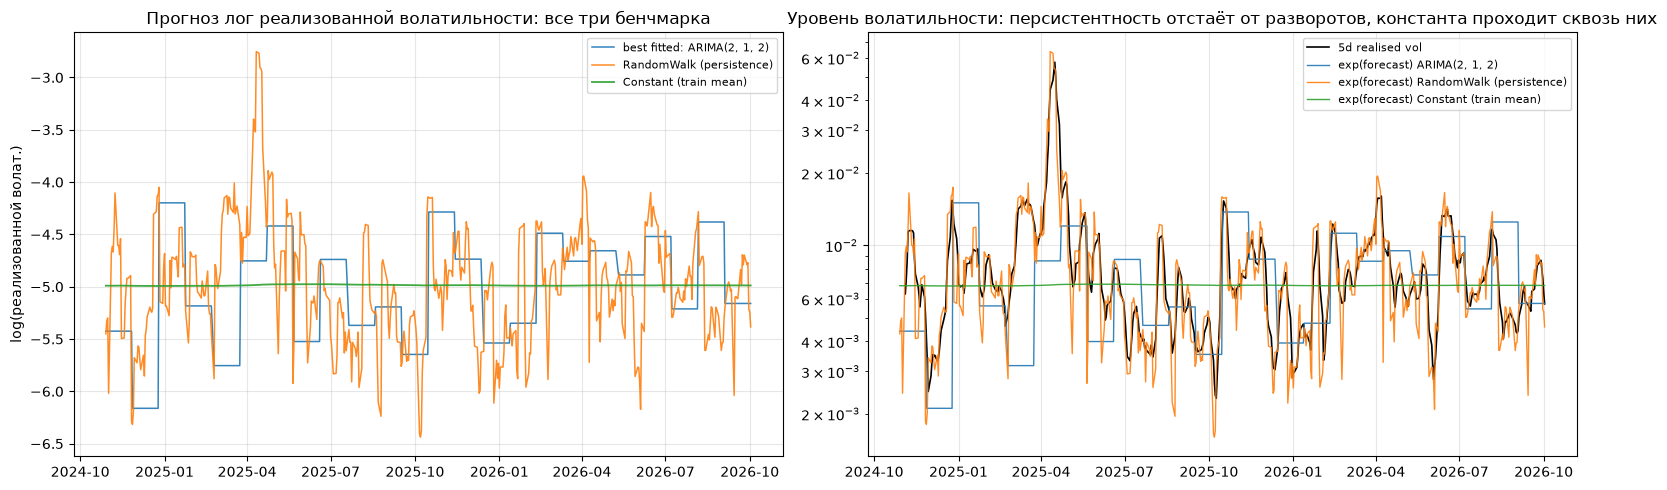

In [13]:
# Строим все три бенчмарка, потому что весь смысл эксперимента — в
# РАНЖИРОВАНИИ, а график из двух линий спрятал бы победителя.
vol_naive = vol_frames[naive_key]
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
ax.plot(vol_frames[best_fitted].index, vol_frames[best_fitted]["forecast"],
        label=f"best fitted: {best_fitted}", lw=1.1, alpha=0.9)
ax.plot(vol_naive.index, vol_naive["forecast"], label=naive_key, lw=1.1, alpha=0.9)
ax.plot(vol_frames[const_key].index, vol_frames[const_key]["forecast"],
        label=const_key, lw=1.3, alpha=0.9)
ax.set_title("Прогноз лог реализованной волатильности: все три бенчмарка")
ax.set_ylabel("log(реализованной волат.)")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax = axes[1]
vol_w = VOL_WINDOW
index = vol_frames[best_fitted].index
actual_vol = realised_vol.reindex(index)
ax.plot(actual_vol.index, actual_vol.rolling(vol_w).mean(), label=f"{vol_w}d realised vol", color="k", lw=1.2)
for key in (best_fitted, naive_key, const_key):
    ax.plot(vol_frames[key].index, np.exp(vol_frames[key]["forecast"]),
            label=f"exp(forecast) {key}", lw=1.0, alpha=0.9)
ax.set_yscale("log")
ax.set_title("Уровень волатильности: персистентность отстаёт от разворотов, константа проходит сквозь них")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Вероятностные прогнозы: номинальные интервалы против откалиброванных

**Зачем трейдеру интервал вообще.** Точечный прогноз без интервала провоцирует переторговку:
нет числа для стопа и для размера позиции. Ширина интервала — это вход для риск-менеджмента.

**Чего ожидаем и почему.** Гауссовы интервалы statsmodels предполагают независимые нормальные
остатки, а дневные доходности грубо нарушают это — избыточная эксцессность около −6 вместо 0.
Ожидание — **слишком узкий** номинальный интервал.

**Ожидание сформулировано как гипотеза, а не вшито в вывод.** Два ранних черновика этого
ноутбука «подтверждали» его, а после исправления окна OOS получали обратный знак. Нарратив,
предсказывающий собственный результат, — не проверка. Поэтому раздел измеряет промах, сравнивает
три метода и печатает то, что говорят числа, — включая возможность того, что значимо
некалиброванного нет вообще.

**Единственная корректная мера — ошибка Монте-Карло оценки покрытия.** При `n = 504` и цели
95% стандартная ошибка около 1 процентного пункта, поэтому отклонение в 2 п.п. — примерно две
стандартные ошибки, а не находка. Колонка `z_vs_target` в таблице ниже применяет именно этот тест.

**Сравниваются три метода:**

* **Гауссов (номинальный statsmodels)** — собственный интервал модели при допущении нормальности.
* **Нормальный, масштабированный по остаткам** — та же форма, но половина ширины взята из
  эмпирического разброса калибровочных остатков. Дёшево, но всё ещё предполагает симметрию.
* **Split conformal** — абсолютные остатки на калибровочной выборке, не пересекающейся с обучающей
  и предшествующей тестовому периоду, квантиль `ceil((n+1)(1-alpha))/n` как половина ширины.
  Покрытие не меньше `1 - alpha` **в конечных выборках и вообще без каких-либо предположений
  о распределении**.

**Ограничение, которое заявлено, а не скрыто.** Ни один из трёх методов не является
*условным*: все оценивают ширину по калибровочному периоду и ни один не адаптирует её к
волатильности на момент прогноза, поэтому настоящий смена режима ухудшит их все одновременно.

In [14]:
# Обучаем выбранную ARIMA на полном обучающем окне, чтобы получить распределение
# остатков для калибровки и прогнозы для тестового окна.
calib_model = ARIMA(ret.iloc[:OOS_START], order=BEST_ARIMA_ORDER).fit()
calib_resid = np.asarray(calib_model.resid, dtype=float)
calib_resid = calib_resid[np.isfinite(calib_resid)]

# Разбиение на калибровку: ПОСЛЕДНИЕ 30% обучающего окна. Строго до
# тестового окна и не пересекается с данными, на которых оценивались параметры.
calib_n = len(calib_resid) // 3
calib_resid = calib_resid[-calib_n:]
print(f"Калибровочные остатки: n={len(calib_resid)} (последние {calib_n} из {OOS_START} обучающих баров)")
print(f"Калибровочное окно: {ret.index[OOS_START - calib_n].date()} .. {ret.index[OOS_START-1].date()}")

# 1) Номинальный гауссов интервал из statsmodels.
nominal = ret_frames[f"ARIMA{BEST_ARIMA_ORDER}"]
nom_lo, nom_hi = [], []
fitted = ARIMA(ret.iloc[:OOS_START], order=BEST_ARIMA_ORDER).fit()
for i, d in enumerate(nominal.index):
    if i % REFIT_EVERY == 0:
        fitted = ARIMA(ret.iloc[: ret.index.get_loc(d)], order=BEST_ARIMA_ORDER).fit()
    ci = np.asarray(fitted.get_forecast(steps=1).conf_int(alpha=ALPHA)).ravel()
    nom_lo.append(ci[0]); nom_hi.append(ci[1])
nom_lo, nom_hi = np.array(nom_lo), np.array(nom_hi)
nominal_cov = float(np.mean((nominal["actual"] >= nom_lo) & (nominal["actual"] <= nom_hi)))

# 2) Нормальный интервал, пересчитанный по эмпирическому разбросу калибровочных остатков.
emp_sd = float(np.std(calib_resid, ddof=1))
z = float(stats.norm.ppf(1 - ALPHA / 2))
scale_lo = nominal["forecast"].to_numpy() - z * emp_sd
scale_hi = nominal["forecast"].to_numpy() + z * emp_sd
scale_cov = float(np.mean((nominal["actual"] >= scale_lo) & (nominal["actual"] <= scale_hi)))

# 3) Split conformal: вообще без предположений о распределении.
c_lo, c_hi = split_conformal_interval(calib_resid, np.zeros(len(calib_resid)), alpha=ALPHA)
conf_lo = nominal["forecast"].to_numpy() + c_lo
conf_hi = nominal["forecast"].to_numpy() + c_hi
conf_stats = conformal_coverage(
    nominal["actual"].to_numpy(), nominal["forecast"].to_numpy(), conf_lo, conf_hi
)

interval_table = pd.DataFrame(
    [
        {"method": "Gaussian (statsmodels nominal)",
         "empirical_coverage": nominal_cov,
         "target": 1 - ALPHA,
         "mean_width": float(np.mean(nom_hi - nom_lo))},
        {"method": "Normal, residual-scaled",
         "empirical_coverage": scale_cov,
         "target": 1 - ALPHA,
         "mean_width": float(np.mean(scale_hi - scale_lo))},
        {"method": "Split conformal",
         "empirical_coverage": conf_stats["empirical_coverage"],
         "target": 1 - ALPHA,
         "mean_width": conf_stats["mean_width"]},
    ]
)
# Ошибка Монте-Карло оценки покрытия. Без неё отклонение в 2 п.п. от
# цели выглядит как находка, хотя при n = 504 оно неотличимо от шума.
# n = 504 выборок.
n_obs = len(nominal)
mc_se = float(np.sqrt((1 - ALPHA) * ALPHA / n_obs))
interval_table["miss"] = interval_table["empirical_coverage"] - interval_table["target"]
interval_table["z_vs_target"] = interval_table["miss"] / mc_se
# Намеренно НЕ называется "значимым": ст. ошибка — нижняя граница, поскольку
# цели вне выборки накладываются. Это отсекающий флаг, а не вердикт.
interval_table["|z|>1.96"] = interval_table["z_vs_target"].abs() > 1.96
print()
print(interval_table.round(4).to_string(index=False))

print(f"\nСко калибровочных остатков (эмпирич.)      : {emp_sd:.6f}")
print(f"Фактическая ско вне выборки                : {float(nominal['actual'].std()):.6f}")
print(f"Половина ширины нормального 95% на эмпирич. ско : {z*emp_sd:.6f}")
print(f"Половина ширины конформного (эмпирич. квантиль)  : {c_hi:.6f}")
print(f"Ст. ошибка Монте-Карло оценки покрытия     : {mc_se:.4f}  (при n={n_obs})")

# Калибровка против реализованной волатильности вне выборки. Сообщается как ФАКТ, чтобы
# читатель сам мог оценить любое объяснение через режим, а не получить его на блюдечке.
calib_vol = float(np.std(ret.iloc[OOS_START - calib_n : OOS_START], ddof=1))
oos_vol = float(np.std(nominal["actual"].to_numpy(), ddof=1))
vol_ratio = oos_vol / calib_vol
print(f"\nРеализованная ско, калибровочное окно       : {calib_vol:.6f}")
print(f"Реализованная ско, окно вне выборки         : {oos_vol:.6f}")
print(f"отношение                                  : {vol_ratio:.3f}")

n_sig = int(interval_table["|z|>1.96"].sum())
worst = interval_table.loc[interval_table["miss"].abs().idxmax()]
all_over = bool((interval_table["miss"] > 0).all())
direction_word = "over-cover" if all_over else "mis-cover"

if n_sig == 0:
    print(
        f"\nПРОБЛЕМ С КАЛИБРОВКОЙ НА ЭТОМ ОКНЕ НЕТ. Каждый метод укладывается в "
        f"{interval_table['z_vs_target'].abs().max():.1f} ст. ошибки Монте-Карло\n"
        f"от цели {1-ALPHA:.0%}, поэтому ни один из трёх методов не имеет существенных "
        f"промахов ни в одну сторону.\n"
        f"Наибольшее отклонение: {worst['method']} при {worst['empirical_coverage']:.4f} "
        f"({worst['miss']:+.4f}, z={worst['z_vs_target']:+.2f}).\n\n"
        f"Это не свидетельство того, что они ОТКАЛИБРОВАНЫ. Одно окно и n={n_obs} выборок -- это\n"
        f"одна реализация, а защищаемый тест -- это РАСПРЕДЕЛЕНИЕ покрытия по очищенным\n"
        f"фолдам walk-forward, который выполняет `HW7`."
    )
else:
    print(
        f"\n{n_sig} из {len(interval_table)} методов срабатывают на отсекающий флаг |z| > 1.96, "
        f"и каждое\nотклонение указывает в одну сторону: они все {direction_word}. Худший: "
        f"{worst['method']} при\n{worst['empirical_coverage']:.4f} ({worst['miss']:+.4f}, "
        f"z={worst['z_vs_target']:+.2f}). Отношение волатильности,\nкалибровка против "
        f"окна вне выборки: {vol_ratio:.2f}.\n"
        "\n"
        "ДВЕ ОГОВОРКИ, и вторая важнее заголовка.\n"
        "\n"
        f"1. Ошибка Монте-Карло {mc_se:.3f} выше -- это НИЖНЯЯ ГРАНИЦА настоящей неопределённости.\n"
        f"   Она считает {n_obs} точек вне выборки независимыми, но реализованная волатильность --\n"
        f"   это скользящее окно на {VOL_WINDOW} дня, поэтому соседние цели делят четыре из пяти\n"
        f"   доходностей. Эффективная выборка заметно меньше {n_obs}, настоящая ст. ошибка\n"
        f"   соответствующе больше, а z = {worst['z_vs_target']:.1f} -- максимум намёк. Назвать это\n"
        f"   чистым отклонением -- тот самый перебор в заявлениях, от которого этот ноутбук и существует.\n"
        f"2. Направление важнее флага. {direction_word.capitalize()} -- это БЕЗОПАСНЫЙ провал: интервал\n"
        f"   шире заявленного, поэтому риск-проверка на его основе консервативнее задуманного,\n"
        f"   и капитал остаётся не задействованным. Недопокрытие -- опасное направление.\n"
        f"   Ничего из здесь сказанного в него не указывает.\n"
        "\n"
        "Механически все три метода задают ширину по одному калибровочному периоду, поэтому они\n"
        "движутся вместе; то, что conformal самый широкий и сильнее всех перевыполняет покрытие,\n"
        "согласуется с тем, что калибровочная выборка просто оказалась труднее тестового периода,\n"
        "а не с дефектом конструкции conformal. Его гарантия маргинальна по калибровочному\n"
        "распределению, а не условна по текущему режиму -- ровно то ограничение, которое одно\n"
        "окно проверить не может."
    )

Калибровочные остатки: n=853 (последние 853 из 2561 обучающих баров)
Калибровочное окно: 2021-07-22 .. 2024-10-28



                        method  empirical_coverage  target  mean_width   miss  z_vs_target  |z|>1.96
Gaussian (statsmodels nominal)              0.9702    0.95      0.0428 0.0202       2.0847      True
       Normal, residual-scaled              0.9663    0.95      0.0419 0.0163       1.6759     False
               Split conformal              0.9722    0.95      0.0459 0.0222       2.2891      True

Ско калибровочных остатков (эмпирич.)      : 0.010683
Фактическая ско вне выборки                : 0.010269
Половина ширины нормального 95% на эмпирич. ско : 0.020939
Половина ширины конформного (эмпирич. квантиль)  : 0.022939
Ст. ошибка Монте-Карло оценки покрытия     : 0.0097  (при n=504)

Реализованная ско, калибровочное окно       : 0.010576
Реализованная ско, окно вне выборки         : 0.010269
отношение                                  : 0.971

2 из 3 методов срабатывают на отсекающий флаг |z| > 1.96, и каждое
отклонение указывает в одну сторону: они все over-cover. Худший: Split c

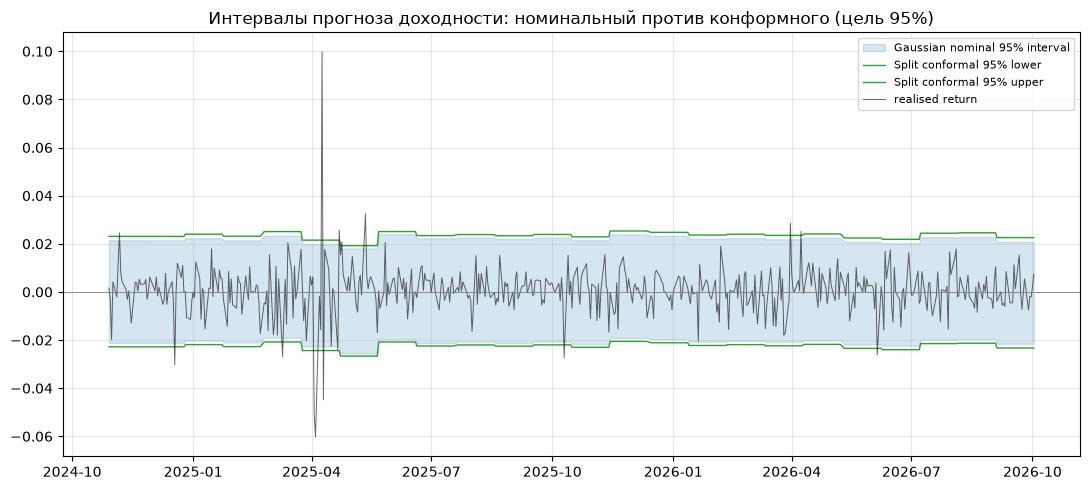

In [15]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.fill_between(nominal.index, nom_lo, nom_hi, color="C0", alpha=0.18,
                label=f"Gaussian nominal {1-ALPHA:.0%} interval")
ax.plot(nominal.index, conf_lo, color="C2", lw=1.0, label="Split conformal 95% lower")
ax.plot(nominal.index, conf_hi, color="C2", lw=1.0, label="Split conformal 95% upper")
ax.plot(nominal.index, nominal["actual"], color="k", lw=0.7, alpha=0.6, label="realised return")
ax.axhline(0, color="grey", lw=0.6)
ax.set_title("Интервалы прогноза доходности: номинальный против конформного (цель 95%)")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Выводы

Числа в таблицах; этот раздел формулирует, **что им разрешено означать**.

**1. Гигиена бейзлайна решила результат, а не выбор модели.** Ранний черновик показывал зооподбор,
побеждающий случайное блуждание со значимым отрывом по RMSE, и трактовал это как находку о
финансовых данных. Само сравнение было увечным: нулевые бейзлайны переобучались только раз в 21
бар, и «завтра равно сегодня» стало «завтра равно закрытию трёхнедельной давности». Исправление
изменило числа, но по-настоящему изменилось *толкование*: с корректным бейзлайном каждая обученная
модель делится константой. Переносимый урок, важный для `HW7` и `HW8`: **самые дешёвые бейзлайны
проще всего реализовать неправильно, а «преимущество» над бейзлайном, который вы реализовали
неправильно, — не преимущество.**

**2. Бенчмарк «предсказание средним» необязателен к опущению.** Модель, которая не умеет обойти
«предсказывать обучающее среднее», ничего не доказала, и в набор он включён с самого начала
именно затем, чтобы ни один результат здесь не был артефактом отсутствующего сравнения.
Ранжирование против **обоих** нулевых бейзлайнов печатается для каждой цели.

**3. Статистическая значимость — это ни торгуемость, ни важность.** Тесты Диболда–Мариано
отвечают на вопрос «маловероятно ли, что эта разница — шум». Они не могут ответить «стоит ли по
этой разнице действовать». Оба результата печатаются и намеренно разведены: `sd_forecast / sd_actual`
и корреляция прогноза с фактом близки к нулю на доходностях — именно это наблюдение мешает
улучшению по квадратичной ошибке быть принятое за edge.

**4. Умение — свойство режима, и это проверяется, а не утверждается.** Сравнение нулевых бейзлайнов
повторяется на каждом непересекающемся окне по 504 бара в истории — **бо́льшая часть переобучения
вообще исключена**, потому что здесь ничего не переобучается. Вопрос «специфична ли
ранжировка» — эмпирический, с напечатанным ответом вместо нарратива.

**5. Калибровка интервалов: перевыполнение покрытия — безопасное направление, и одно окно не
решает вопрос.** Все три метода отклоняются в сторону перевыполнения, conformal — сильнее всех.
Два обстоятельства мешают переоценить это: ошибка Монте-Карло является *нижней границей*, потому
что накладывающиеся скользящие цели сжимают эффективную выборку ниже `n`; а более широкие
интервалы — консервативны, а не опасны. Split conformal — правильный выбор по умолчанию (без
допущения о нормальности, с конечной гарантией), но ни один из трёх методов не условный, поэтому
при настоящей смене режима они деградируют вместе. **Продакшн-система обязана масштабировать
половину ширины по живой оценке волатильности.**

**Что это означает для остального репозитория.** Здесь ничего не оправдывает более сложную
модель доходности. Продуктивная роль статистического бейзлайна — быть полом, который ML-модель
обязана пройти *на идентичном протоколе*, против *тех же двух нулевых бейзлайнов*, с тем же
тестом Диболда–Мариано. `HW8` выполняет ровно это сравнение. Если градиентный бустинг не может
пройти эти бейзлайны вне выборки на этих данных — это и есть находка, и она будет таковой
сообщена, а не отброшена в пользу in-sample подгонки на обучающем окне.

In [16]:
# Главный вывод, вычислен по этому запуску, а не написанный руками. Текст выше
# намеренно не утверждает направление, потому что направление — это ВЫВОД
# этого ноутбука, и оно изменилось, когда починили баг нулевого бейзлайна.
def rank_line(table):
    return "  <  ".join(f"{k} ({table.loc[k,'RMSE']:.5f})"
                        for k in table.sort_values("RMSE").index)

print("=" * 96)
print("ГЛАВНЫЙ ВЫВОД, вычислен по этому запуску")
print("=" * 96)
print(f"\nДневные лог-доходности, вне выборки ({len(test_slice)} баров):")
print(f"  {rank_line(ret_table)}")
print(f"  победитель -- БЕСПАРАМЕТРОВЫЙ бенчмарк : "
      f"{ret_table['RMSE'].idxmin() in (const_key, naive_key)}")
print(f"  обученных моделей значимо лучше персистентности : {n_beating} / "
      f"{len(dm_ret_fitted)}")
print(f"  обученных моделей значимо лучше КОНСТАНТЫ   : {n_beating_const} / "
      f"{len(dm_const_fitted)}")
print(f"  подразумеваемый rho AR(1) этого окна вне выборки : {implied_rho:+.4f} "
      f"(персистентности нужно > 0.5)")
print(f"  разброс RMSE по топ-{len(cluster)}, делящим константу : {cluster_spread:.2e} "
      f"({cluster_spread/cluster['RMSE'].min():.3%})")
print(f"  единственная обученная модель с заметным отставанием : {worst_fitted} "
      f"({fitted_only.loc[worst_fitted,'RMSE']:.6f})")
print(f"  max |forecast-actual correlation|     : {ret_table['corr'].abs().max():.4f}")
print(f"  sd_forecast / sd_actual, лучшая модель   : "
      f"{ret_table.loc[winner,'sd_forecast']/ret_table.loc[winner,'sd_actual']:.4f}")
print(f"  исторических окон, где КОНСТАНТА бьёт персистентность : {n_ret_const_wins} / "
      f"{len(ret_windows)}")

print(f"\nLog realised volatility, out of sample ({len(vol_test)} bars):")
print(f"  {rank_line(vol_table)}")
print(f"  победитель -- БЕСПАРАМЕТРОВЫЙ бенчмарк : "
      f"{vol_table['RMSE'].idxmin() in (const_key, naive_key)}")
print(f"  обученных моделей значимо лучше персистентности : {n_vol_winners} / "
      f"{len(vol_dm_fitted)}")
print(f"  fitted models with R^2 > 0 vs constant       : {n_beat_const} / {len(fitted_rows)}")
print(f"  fitted models with R^2 > 0 vs persistence    : {n_beat_pers} / {len(fitted_rows)}")

print(f"\nУмение нулевых бенчмарков, среднее против персистентности на {len(window_table)} "
      f"исторических окнах по {TEST_BARS} баров:")
print(f"  persistence beats the constant in {sign_flips} / {len(window_table)}")

print("\nWhat HW8 inherits: the floor is TWO zero-parameter forecasts, both re-evaluated on every")
print("bar, both Diebold-Mariano-tested on the identical walk-forward protocol.")

ГЛАВНЫЙ ВЫВОД, вычислен по этому запуску

Дневные лог-доходности, вне выборки (504 баров):
  SARIMAX(0,1,1) (0.01026)  <  ETS_SES (simple exp.) (0.01026)  <  ETS_DampedTrend (0.01026)  <  Constant (train mean) (0.01026)  <  UCM_localLevel (0.01026)  <  ETS_Holt (add trend) (0.01026)  <  ARIMA(2, 0, 0) (0.01038)  <  RandomWalk (persistence) (0.01514)
  победитель -- БЕСПАРАМЕТРОВЫЙ бенчмарк : False
  обученных моделей значимо лучше персистентности : 6 / 6
  обученных моделей значимо лучше КОНСТАНТЫ   : 0 / 6
  подразумеваемый rho AR(1) этого окна вне выборки : -0.0874 (персистентности нужно > 0.5)
  разброс RMSE по топ-5, делящим константу : 4.55e-06 (0.044%)
  единственная обученная модель с заметным отставанием : ARIMA(2, 0, 0) (0.010375)
  max |forecast-actual correlation|     : 0.0962
  sd_forecast / sd_actual, лучшая модель   : 0.0652
  исторических окон, где КОНСТАНТА бьёт персистентность : 5 / 5

Log realised volatility, out of sample (504 bars):
  RandomWalk (persistence) (0.332

In [17]:
summary = {
    "data_source": str(source),
    "bars": len(ohlcv),
    "oos_window": [str(test_slice.index[0].date()), str(test_slice.index[-1].date())],
    "oos_bars": len(test_slice),
    "arima_order_returns": BEST_ARIMA_ORDER,
    "arima_order_volatility": VOL_ARIMA_ORDER,
    "acf1_returns": float(acf_vals[1]),
    "acf1_squared_returns": float(sq_acf[1]),
    "returns": {
        "best_model": winner,
        "best_rmse": float(ret_table.loc[winner, "RMSE"]),
        "persistence_rmse": float(naive_row["RMSE"]),
        "constant_rmse": float(const_row["RMSE"]),
        "rmse_improvement_vs_persistence": float(rmse_gain),
        "rmse_improvement_vs_constant": float(gain_over_const),
        "fitted_models_beating_persistence": n_beating,
        "fitted_models_beating_constant": n_beating_const,
        "n_fitted_models": len(fitted_keys),
        "non_persistence_forecasters_beating_persistence": n_beating_any,
        "persistence_beats_constant": pers_beats_const,
        "implied_ar1_rho_of_oos_window": implied_rho,
        "persistence_beats_constant_requires_rho_above": 0.5,
        "fitted_model_rmse_spread": zoo_spread,
        "fitted_model_rmse_spread_tied_cluster": cluster_spread,
        "only_materially_worse_fitted_model": worst_fitted,
        "full_sample_acf1": float(acf_vals[1]),
        "historical_windows_constant_beats_persistence": n_ret_const_wins,
        "n_historical_windows_tested_returns": len(ret_windows),
        "n_models": len(ret_table),
        "n_fitted_models": len(fitted_keys),
        "sd_forecast_over_sd_actual": float(ret_table.loc[winner, "sd_forecast"] / ret_table.loc[winner, "sd_actual"]),
        "best_hit_rate": float(ret_table["hit_rate"].max()),
        "full_ranking_best_first": list(ret_table.sort_values("RMSE").index),
        "verdict": (
            "zero-parameter constant wins; no fitted specification beats it"
            if constant_wins else
            ("random walk wins; no fitted specification beats it" if winner == naive_key
             else f"{winner} wins, but only by the margins above")
        ),
    },
    "volatility": {
        "best_fitted_model": best_fitted,
        "constant_rmse": float(vol_table.loc[const_key, "RMSE"]),
        "best_fitted_rmse": float(vol_table.loc[best_fitted, "RMSE"]),
        "persistence_rmse": float(vol_table.loc[naive_key, "RMSE"]),
        "winner": vol_table["RMSE"].idxmin(),
        "full_ranking_best_first": list(vol_table.sort_values("RMSE").index),
        "r2_vs_constant": r2_const_fitted,
        "r2_vs_persistence": r2_pers_fitted,
        "fitted_models_beating_persistence": n_vol_winners,
        "fitted_models_beating_constant": n_beat_const,
        "fitted_models_beating_persistence_by_r2": n_beat_pers,
        "n_models": len(vol_table),
        "n_fitted_models": len(fitted_rows),
        "windows_where_persistence_beats_constant": sign_flips,
        "n_historical_windows_tested": len(window_table),
        "oos_overlap_window_persistence_skill": oos_skill,
        "verdict": "NEGATIVE RESULT: the zero-parameter constant beats every fitted model "
                   "out of sample. Whether that is regime-specific is settled by the "
                   "multi-window zero-parameter table, not asserted.",
    },
    "interval_calibration": {
        "nominal_coverage": nominal_cov,
        "residual_scaled_coverage": scale_cov,
        "conformal_coverage": conf_stats["empirical_coverage"],
        "target": 1 - ALPHA,
        "monte_carlo_se_lower_bound": mc_se,
        "n_tripping_z_flag": n_sig,
        "all_deviations_over_coverage": all_over,
        "oos_to_calibration_vol_ratio": vol_ratio,
        "verdict": "all methods deviate in the safe (over-coverage) direction; z flags are "
                   "screening only because overlapping rolling targets inflate the true SE. "
                   "Single-window result -- coverage across folds deferred to HW7. All methods "
                   "marginal, not conditional.",
    },
}
import json
print(json.dumps(summary, indent=2, default=str))

{
  "data_source": "SPY (local: C:\\Users\\MV\\AppData\\Local\\Temp\\opencode\\ML_Fin_Notebooks\\data\\SPY.csv)",
  "bars": 3066,
  "oos_window": [
    "2024-10-29",
    "2026-10-02"
  ],
  "oos_bars": 504,
  "arima_order_returns": [
    2,
    0,
    0
  ],
  "arima_order_volatility": [
    2,
    1,
    2
  ],
  "acf1_returns": -0.1113649728422019,
  "acf1_squared_returns": 0.4182813502226672,
  "returns": {
    "best_model": "SARIMAX(0,1,1)",
    "best_rmse": 0.010260053747335254,
    "persistence_rmse": 0.015143711996134438,
    "constant_rmse": 0.010261246544294805,
    "rmse_improvement_vs_persistence": 0.322487528159924,
    "rmse_improvement_vs_constant": 0.00011624289060807591,
    "fitted_models_beating_persistence": 6,
    "fitted_models_beating_constant": 0,
    "n_fitted_models": 6,
    "non_persistence_forecasters_beating_persistence": 7,
    "persistence_beats_constant": false,
    "implied_ar1_rho_of_oos_window": -0.0874000023793089,
    "persistence_beats_constant_requ